#Start

In [ ]:
# Google Drive Permissions
from google.colab import drive
drive.mount('/content/drive')

# Package instalation
%pip install folium
%pip install gurobipy
%pip install pulp
%pip install pykrige
%pip install scipy

# Libs import
import pandas as pd
import os
import numpy as np
import folium
import geopandas as gpd
from pykrige.ok import OrdinaryKriging
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.metrics import mean_absolute_error, mean_squared_error
from geopy.distance import geodesic


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 25.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 32.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 854.9/854.9 kB 9.6 MB/s eta 0:00:00


# Data Manipulation

## Read Data

In [ ]:
# Diretório onde estão os arquivos
dir_path = "/content/drive/My Drive/Projeto/SJC/"

# Cria um dicionário para armazenar as informações de todos os arquivos
dfs = {}

data_init = 2019
data_fin = 2024

# Itera sobre os diretórios e arquivos para carregar as informações em cada dataframe
for year in range(data_init, data_fin):
    dfs[year] = {}
    for month in ['J', 'F', 'M']:
        filename = f'data_{month}.csv'
        filepath = os.path.join(dir_path, str(year), filename)
        if os.path.isfile(filepath):
            dfs[year][month] = pd.read_csv(filepath, usecols=['nomeEstacao', 'latitude', 'longitude', 'datahora', 'valorMedida'], sep=';', decimal=',')

# Concatena os dataframes em um único dataframe
df = pd.concat((dfs[year][month] for year in range(data_init, data_fin) for month in ['J', 'F', 'M']), axis=0)

# Converte a coluna 'datahora' para datetime
df['datahora'] = pd.to_datetime(df['datahora'])

# Converte a coluna valorMedida para float
df['valorMedida'] = pd.to_numeric(df['valorMedida'])

# Cria uma coluna 'localizacao' que combina a latitude e a longitude de cada estação pluviométrica
df['localizacao'] = df['latitude'].astype(str) + ',' + df['longitude'].astype(str)

# Cria uma coluna 'ano_mes' que combina o ano e o mês
df['ano_mes'] = df['datahora'].dt.to_period('M')

# Agrupa os dados por 'localizacao', 'ano_mes' e calcula a soma dos valores de medida
df = df.groupby(['localizacao', 'ano_mes']).agg({'nomeEstacao': 'first', 'valorMedida': 'sum'}).reset_index()

# Cria um dataframe 'localizacoes' que contém todas as localizações únicas e os nomes das estações associadas
localizacoes = df.groupby('localizacao').agg({'nomeEstacao': lambda x: list(set(x))}).reset_index()

# Cria uma coluna 'nomes' que concatena os nomes das estações que têm a mesma localização
localizacoes['nomes'] = localizacoes['nomeEstacao'].apply(lambda x: ' / '.join(x))

# Cria um dataframe 'pivot' que transforma os valores de 'ano_mes' em colunas e preenche os valores de medida
pivot = df.pivot(index='localizacao', columns='ano_mes', values='valorMedida').reset_index()

# Converte as colunas 'ano_mes' para strings sem caracteres especiais
pivot.columns = pivot.columns.astype(str)
pivot.columns = pivot.columns.str.replace('[^a-zA-Z0-9]', '_')  # Substitui caracteres especiais por underscore

# Cria uma coluna 'nomes' que concatena os nomes das estações que têm a mesma localização
pivot = pivot.merge(localizacoes[['localizacao', 'nomes']], on='localizacao', how='left')

# Separa a coluna 'localizacao' em 'latitude' e 'longitude'
pivot[['latitude', 'longitude']] = pivot['localizacao'].str.split(',', expand=True)

# Converte as colunas 'latitude' e 'longitude' para float
pivot['latitude'] = pivot['latitude'].astype(float)
pivot['longitude'] = pivot['longitude'].astype(float)

# Remove as colunas desnecessárias
pivot = pivot.drop(columns=['localizacao'])

# Reordena as colunas
pivot = pivot[['nomes', 'latitude', 'longitude'] + [col for col in pivot.columns if col not in ['nomes', 'latitude', 'longitude']]]

# Mostra o dataframe final
pivot


,nomes,latitude,longitude,2019-01,2019-02,2019-03,2020-01,2020-02,2020-03,2021-01,2021-02,2021-03,2022-01,2022-02,2022-03,2023-01,2023-02,2023-03
0,Chacara Boa Vista,-23.087000,-45.931000,NaN,NaN,NaN,236.15,427.21,131.20,151.97,372.86,114.46,453.40,141.57,172.24,159.23,413.83,174.06
1,Freitas,-23.109000,-45.933000,0.00,0.00,236.44,NaN,NaN,NaN,172.11,210.17,43.30,169.23,72.66,183.20,170.45,214.09,31.80
2,Buquirinha,-23.111000,-45.913000,222.22,335.94,166.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Jardim Santa Matilde,-23.140000,-45.903000,NaN,5.94,84.91,0.00,NaN,NaN,218.79,445.23,96.11,158.79,58.73,158.72,116.56,34.60,15.40
4,Altos Vila Paiva,-23.143000,-45.920000,207.90,250.67,166.62,232.83,279.32,87.91,113.85,199.25,97.20,136.37,NaN,152.51,0.00,314.18,109.49
5,Parque Tecnológico SJC (TESTES) / Parque Tecno...,-23.157460,-45.794410,73.60,272.60,131.20,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Parque Tecnológico SJC (TESTES HIDRO CAMPBELL),-23.157799,-45.793511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.40,NaN
7,Parque Tecnológico SJC (TESTES HIDRO VAISALA),-23.157799,-45.793666,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,325.40,159.60
8,Parque Tecnológico SJC (TESTES PLUVIO),-23.157954,-45.793500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,387.00,107.00
9,Parque Tecnológico SJC (TESTES HIDRO CAMPBELL),-23.158053,-45.793461,NaN,NaN,NaN,62.60,379.60,103.20,191.60,424.40,94.00,NaN,0.40,44.20,NaN,NaN,NaN


## New Data

In [ ]:
# Diretório dos arquivos
dir_path = "/content/drive/My Drive/Projeto/SJC/2024/"

# Ler os arquivos
localizacoes_file = "localizacoes.xltx"
novas_file = "novas.xlsx"  # Certifique-se de corrigir o nome do arquivo, se necessário

# Caminho completo para os arquivos
localizacoes_path = dir_path + localizacoes_file
novas_path = dir_path + novas_file

# Ler os arquivos em DataFrames
localizacoes_df = pd.read_excel(localizacoes_path)
novas_df = pd.read_excel(novas_path)

# Juntar os DataFrames
novas_loc = pd.merge(localizacoes_df, novas_df[['numero', 'Total']], on='numero')

# Selecionar as colunas desejadas
novas_loc = novas_loc[['nome', 'latitude', 'longitude', 'Total']]

# Renomear as colunas
novas_loc.columns = ['nome', 'latitude', 'longitude', 'Total']

# Exibir o DataFrame final
#novas_loc

## Imputation

In [ ]:
# Calcula a média dos valores mensais para cada estação
pivot['media'] = pivot.loc[:, pivot.columns[3:]].mean(axis=1)

# Preenche os valores faltantes de cada ano com a média correspondente
pivot.loc[:, pivot.columns[3:]] = pivot.loc[:, pivot.columns[3:]].apply(
    lambda col: col.fillna(pivot['media'])
)

# Substitui os valores menores do que 1 por pivot['media']
pivot.loc[:, pivot.columns[3:]] = pivot.loc[:, pivot.columns[3:]].mask(
    pivot.loc[:, pivot.columns[3:]] < 1, pivot['media'], axis=0
)

# Adiciona as médias mensais ao DataFrame
pivot['media_j'] = pivot.filter(like='-01').mean(axis=1, skipna=True)
pivot['media_f'] = pivot.filter(like='-02').mean(axis=1, skipna=True)
pivot['media_m'] = pivot.filter(like='-03').mean(axis=1, skipna=True)

# Mostra o dataframe final
pivot


,nomes,latitude,longitude,2019-01,2019-02,2019-03,2020-01,2020-02,2020-03,2021-01,...,2022-01,2022-02,2022-03,2023-01,2023-02,2023-03,media,media_j,media_f,media_m
0,Chacara Boa Vista,-23.087000,-45.931000,245.681667,245.681667,245.681667,236.150000,427.210000,131.200000,151.970000,...,453.400000,141.570000,172.240000,159.230000,413.830000,174.060000,245.681667,249.286333,320.230333,167.528333
1,Freitas,-23.109000,-45.933000,125.287500,125.287500,236.440000,125.287500,125.287500,125.287500,172.110000,...,169.230000,72.660000,183.200000,170.450000,214.090000,31.800000,125.287500,152.473000,149.499000,124.005500
2,Buquirinha,-23.111000,-45.913000,222.220000,335.940000,166.940000,241.700000,241.700000,241.700000,241.700000,...,241.700000,241.700000,241.700000,241.700000,241.700000,241.700000,241.700000,237.804000,260.548000,226.748000
3,Jardim Santa Matilde,-23.140000,-45.903000,116.148333,5.940000,84.910000,116.148333,116.148333,116.148333,218.790000,...,158.790000,58.730000,158.720000,116.560000,34.600000,15.400000,116.148333,145.287333,132.129667,94.257667
4,Altos Vila Paiva,-23.143000,-45.920000,207.900000,250.670000,166.620000,232.830000,279.320000,87.910000,113.850000,...,136.370000,167.721429,152.510000,167.721429,314.180000,109.490000,167.721429,171.734286,242.228286,122.746000
5,Parque Tecnológico SJC (TESTES) / Parque Tecno...,-23.157460,-45.794410,73.600000,272.600000,131.200000,79.566667,79.566667,79.566667,79.566667,...,79.566667,79.566667,79.566667,79.566667,79.566667,79.566667,79.566667,78.373333,118.173333,89.893333
6,Parque Tecnológico SJC (TESTES HIDRO CAMPBELL),-23.157799,-45.793511,0.400000,0.400000,0.400000,0.400000,0.400000,0.400000,0.400000,...,0.400000,0.400000,0.400000,0.400000,0.400000,0.400000,0.400000,0.400000,0.400000,0.400000
7,Parque Tecnológico SJC (TESTES HIDRO VAISALA),-23.157799,-45.793666,242.500000,242.500000,242.500000,242.500000,242.500000,242.500000,242.500000,...,242.500000,242.500000,242.500000,242.500000,325.400000,159.600000,242.500000,242.500000,259.080000,225.920000
8,Parque Tecnológico SJC (TESTES PLUVIO),-23.157954,-45.793500,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,...,247.000000,247.000000,247.000000,247.000000,387.000000,107.000000,247.000000,247.000000,275.000000,219.000000
9,Parque Tecnológico SJC (TESTES HIDRO CAMPBELL),-23.158053,-45.793461,162.500000,162.500000,162.500000,62.600000,379.600000,103.200000,191.600000,...,162.500000,162.500000,44.200000,162.500000,162.500000,162.500000,162.500000,148.340000,258.300000,113.280000


## Corrections

In [ ]:
# Filtra os dados para selecionar apenas as estações pluviométricas do parque tecnológico
parque = pivot[pivot['nomes'].str.contains('^Parque Tecnol[oó]gico SJC')]

# Ordena os dados por 'localizacao' e 'media' em ordem decrescente
parque = parque.sort_values(by=['media'], ascending=False)

# Seleciona as 3 primeiras linhas, que correspondem às 3 localizações com o maior valor da média de todos os anos
parque = parque.head(3)

# Calcula a média dos valores de medida dessas 3 localizações para cada ano
valores = parque.iloc[:, 1:].mean()

# Calcula a média ponderada das latitudes e longitudes dessas 3 localizações, usando os valores da média como pesos
lat = np.average(parque['latitude'], weights=parque['media'])
lon = np.average(parque['longitude'], weights=parque['media'])

# Cria uma nova linha com o nome "Parque Tecnológico" e os valores calculados
nova_linha = pd.Series({'nomes': 'Parque tecnológico', 'latitude': lat, 'longitude': lon, **valores.to_dict()})

# Remove as linhas das estações pluviométricas do parque tecnológico do dataframe original
pivot = pivot[~pivot['nomes'].str.contains('^Parque Tecnol[oó]gico SJC')]

# Crie um novo DataFrame com a linha que você deseja adicionar
nova_linha_df = pd.DataFrame([nova_linha])

# Concatene o novo DataFrame com o DataFrame original
pivot = pd.concat([pivot, nova_linha_df], ignore_index=True)

# Mostra o dataframe final
pivot


,nomes,latitude,longitude,2019-01,2019-02,2019-03,2020-01,2020-02,2020-03,2021-01,...,2022-01,2022-02,2022-03,2023-01,2023-02,2023-03,media,media_j,media_f,media_m
0,Chacara Boa Vista,-23.087000,-45.931000,245.681667,245.681667,245.681667,236.150000,427.210000,131.200000,151.970000,...,453.400000,141.570000,172.240000,159.230000,413.830000,174.06,245.681667,249.286333,320.230333,167.528333
1,Freitas,-23.109000,-45.933000,125.287500,125.287500,236.440000,125.287500,125.287500,125.287500,172.110000,...,169.230000,72.660000,183.200000,170.450000,214.090000,31.80,125.287500,152.473000,149.499000,124.005500
2,Buquirinha,-23.111000,-45.913000,222.220000,335.940000,166.940000,241.700000,241.700000,241.700000,241.700000,...,241.700000,241.700000,241.700000,241.700000,241.700000,241.70,241.700000,237.804000,260.548000,226.748000
3,Jardim Santa Matilde,-23.140000,-45.903000,116.148333,5.940000,84.910000,116.148333,116.148333,116.148333,218.790000,...,158.790000,58.730000,158.720000,116.560000,34.600000,15.40,116.148333,145.287333,132.129667,94.257667
4,Altos Vila Paiva,-23.143000,-45.920000,207.900000,250.670000,166.620000,232.830000,279.320000,87.910000,113.850000,...,136.370000,167.721429,152.510000,167.721429,314.180000,109.49,167.721429,171.734286,242.228286,122.746000
5,Jardim Altos de Santana,-23.159000,-45.916000,233.550000,247.400000,197.060000,234.720000,286.080000,91.530000,243.930000,...,135.130000,96.300000,146.440000,228.820000,349.880000,111.76,207.919333,215.230000,281.980000,126.548000
6,Jardim Jussara / Jardim Juçara,-23.187000,-45.869000,2.600000,13.040000,73.177692,34.660000,2.800000,4.600000,73.177692,...,73.177692,73.177692,145.300000,158.100000,415.050000,137.71,73.177692,68.343077,115.449077,79.487538
7,Jardim São Leopoldo,-23.244000,-45.825000,208.420000,292.590000,201.700000,218.420000,323.800000,63.220000,171.060000,...,225.280714,625.830000,158.650000,178.410000,316.470000,132.58,225.280714,200.318143,339.988000,135.536000
8,Rio comprido,-23.256000,-45.941000,93.720000,101.028667,101.028667,65.800000,42.190000,101.028667,2.400000,...,207.780000,138.340000,244.470000,115.630000,351.270000,188.67,101.028667,97.066000,146.771467,139.911467
9,Parque tecnológico,-23.157943,-45.793501,255.666667,255.666667,255.666667,255.666667,255.666667,255.666667,255.666667,...,255.666667,255.666667,255.666667,255.666667,364.333333,147.00,255.666667,255.666667,277.400000,233.933333


In [ ]:
pivot

,nomes,latitude,longitude,2019-01,2019-02,2019-03,2020-01,2020-02,2020-03,2021-01,...,2022-01,2022-02,2022-03,2023-01,2023-02,2023-03,media,media_j,media_f,media_m
0,Chacara Boa Vista,-23.087000,-45.931000,245.681667,245.681667,245.681667,236.150000,427.210000,131.200000,151.970000,...,453.400000,141.570000,172.240000,159.230000,413.830000,174.06,245.681667,249.286333,320.230333,167.528333
1,Freitas,-23.109000,-45.933000,125.287500,125.287500,236.440000,125.287500,125.287500,125.287500,172.110000,...,169.230000,72.660000,183.200000,170.450000,214.090000,31.80,125.287500,152.473000,149.499000,124.005500
2,Buquirinha,-23.111000,-45.913000,222.220000,335.940000,166.940000,241.700000,241.700000,241.700000,241.700000,...,241.700000,241.700000,241.700000,241.700000,241.700000,241.70,241.700000,237.804000,260.548000,226.748000
3,Jardim Santa Matilde,-23.140000,-45.903000,116.148333,5.940000,84.910000,116.148333,116.148333,116.148333,218.790000,...,158.790000,58.730000,158.720000,116.560000,34.600000,15.40,116.148333,145.287333,132.129667,94.257667
4,Altos Vila Paiva,-23.143000,-45.920000,207.900000,250.670000,166.620000,232.830000,279.320000,87.910000,113.850000,...,136.370000,167.721429,152.510000,167.721429,314.180000,109.49,167.721429,171.734286,242.228286,122.746000
5,Jardim Altos de Santana,-23.159000,-45.916000,233.550000,247.400000,197.060000,234.720000,286.080000,91.530000,243.930000,...,135.130000,96.300000,146.440000,228.820000,349.880000,111.76,207.919333,215.230000,281.980000,126.548000
6,Jardim Jussara / Jardim Juçara,-23.187000,-45.869000,2.600000,13.040000,73.177692,34.660000,2.800000,4.600000,73.177692,...,73.177692,73.177692,145.300000,158.100000,415.050000,137.71,73.177692,68.343077,115.449077,79.487538
7,Jardim São Leopoldo,-23.244000,-45.825000,208.420000,292.590000,201.700000,218.420000,323.800000,63.220000,171.060000,...,225.280714,625.830000,158.650000,178.410000,316.470000,132.58,225.280714,200.318143,339.988000,135.536000
8,Rio comprido,-23.256000,-45.941000,93.720000,101.028667,101.028667,65.800000,42.190000,101.028667,2.400000,...,207.780000,138.340000,244.470000,115.630000,351.270000,188.67,101.028667,97.066000,146.771467,139.911467
9,Parque tecnológico,-23.157943,-45.793501,255.666667,255.666667,255.666667,255.666667,255.666667,255.666667,255.666667,...,255.666667,255.666667,255.666667,255.666667,364.333333,147.00,255.666667,255.666667,277.400000,233.933333


## map

In [ ]:
# Cria um mapa com a localização de São José dos Campos
mapa = folium.Map(location=[-23.1791, -45.8872], zoom_start=10)

# Adiciona um círculo vermelho para cada localização, com o tamanho proporcional à média de valores
for lat, lon, val in zip(novas_loc['latitude'], novas_loc['longitude'], novas_loc['Total']):
  folium.CircleMarker(location=[lat, lon], radius=val/50, color='blue', fill=True).add_to(mapa)

# Adiciona um círculo vermelho para cada localização, com o tamanho proporcional à média de valores
for lat, lon, val in zip(pivot['latitude'], pivot['longitude'], pivot['media_j']):
  folium.CircleMarker(location=[lat, lon], radius=val/50, color='red', fill=True).add_to(mapa)


# Mostra o mapa
mapa

# Interpolation Methods

In [ ]:
#Define a coluna de dados fonte a serem interpoladas
pivot['data'] = pivot['media_j']

# Define a função de criar um grid de novas localizações
def NovasLocalizacoes(df, n, expand):
  # Calcula os limites das localizações existentes em latitude e longitude
  lat_min = df['latitude'].min()
  lat_max = df['latitude'].max()
  lon_min = df['longitude'].min()
  lon_max = df['longitude'].max()
  # Expande os limites de acordo com o valor de expand
  lat_range = lat_max - lat_min
  lon_range = lon_max - lon_min
  lat_min = lat_min - expand * lat_range
  lat_max = lat_max + expand * lat_range
  lon_min = lon_min - expand * lon_range
  lon_max = lon_max + expand * lon_range
  # Cria n novas localizações geográficas em cada direção, formando um grid quadrado
  new_lats = np.linspace(lat_min, lat_max, n)
  new_lons = np.linspace(lon_min, lon_max, n)
  new_locs = np.meshgrid(new_lats, new_lons)
  # Cria um dataframe com as novas localizações e os nomes baseados na posição do grid
  new_df = pd.DataFrame({
      'latitude': new_locs[0].ravel(),
      'longitude': new_locs[1].ravel()
  })
  new_df['nomeEstacao'] = 'Loc_' + (new_df.index // n + 1).astype(str) + 'x' + (new_df.index % n + 1).astype(str)
  # Retorna o dataframe com as novas localizações
  return new_df


##IDW (Inverse Distance Weighting):
O método de IDW é uma técnica de interpolação que atribui valores a pontos desconhecidos com base nas distâncias inversas ponderadas dos pontos conhecidos mais próximos. A fórmula para IDW é dada por:

\begin{equation}
\hat{Z}(\mathbf{u}) = \frac{\sum_{i=1}^{n} w_i Z(\mathbf{u}i)}{\sum{i=1}^{n} w_i}
\tag{1}
\end{equation}

Onde Z é uma variável que está sendo interpolada no ponto de interesse u, n é o número de pontos conhecidos, Z(ui) é o valor da variável nos pontos conhecidos Ui, e Wi são os pesos atribuídos com base nas distâncias inversas.


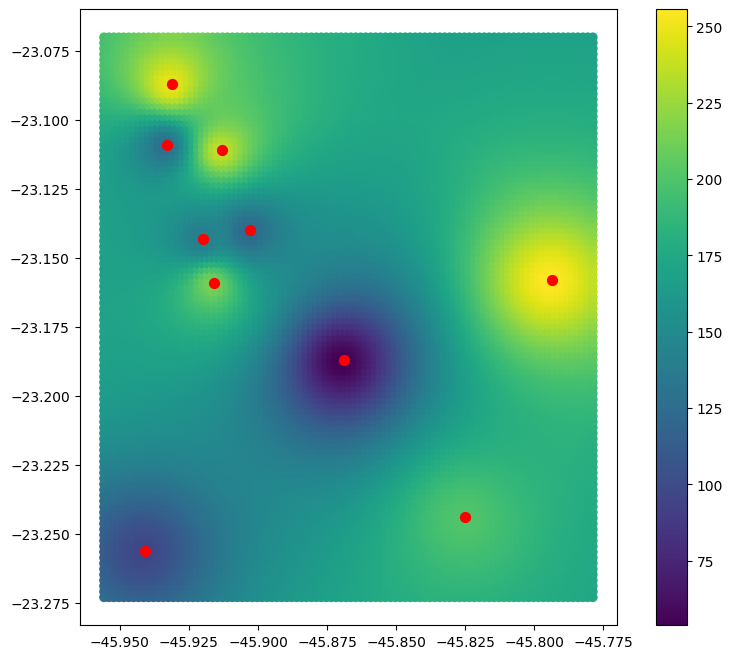

In [ ]:
intepolation_IDW = NovasLocalizacoes(pivot, n=100, expand=0.1)

# Calcula a matriz de distâncias entre as localizações interpoladas e as existentes
delta_lat = intepolation_IDW['latitude'].values[:, np.newaxis] - pivot['latitude'].values
delta_lon = intepolation_IDW['longitude'].values[:, np.newaxis] - pivot['longitude'].values
distances = np.sqrt(delta_lat**2 + delta_lon**2)

# Função para converter distância em quilômetros para graus de latitude e longitude
def km_to_degrees(distance_km):
    # Coordenadas de referência para cálculo (pode ser qualquer coordenada válida)
    reference_point = (0, 0)
    # Calcula a distância em graus de latitude e longitude correspondente à distância em quilômetros
    distance_deg = geodesic(kilometers=distance_km).destination(reference_point, 90).longitude - reference_point[0]
    return distance_deg

# Distância em quilômetros
distancia_km = 10

# Converter a distância para a unidade de distância adequada ao código
max_distance = km_to_degrees(distancia_km)

# Aplica um limite superior às distâncias
distances[distances > max_distance] = max_distance

# Calcula o inverso das distâncias elevadas a 2
peso_dist = 3000 # Peso das distâncias no cálculo
inverted_distances = (distances*peso_dist)**2
inverted_distances = 1 / inverted_distances

# Normaliza os pesos para que a soma seja igual a 1
weights_sum = np.sum(inverted_distances, axis=1, keepdims=True)
normalized_weights = inverted_distances / weights_sum

# Calcula os novos valores usando operações vetorizadas
values = np.sum(normalized_weights * pivot['data'].values, axis=1)

# Adiciona os valores ao DataFrame
intepolation_IDW['value'] = values.copy()

# Cria um GeoDataFrame a partir do DataFrame
gdf = gpd.GeoDataFrame(pivot, geometry=gpd.points_from_xy(pivot['longitude'], pivot['latitude']))

result_gdf = gpd.GeoDataFrame(intepolation_IDW,
                              geometry=gpd.points_from_xy(intepolation_IDW['longitude'],
                                                          intepolation_IDW['latitude']))

# Plota os resultados
fig, ax = plt.subplots(figsize=(10, 8))
result_gdf.plot(ax=ax, column='value', cmap='viridis', legend=True, label='Interpolação por IDW')
gdf.plot(ax=ax, color='red', markersize=50, label='Dados Observados')
plt.show()

## Krigagem:
A krigagem é uma técnica de interpolação que leva em consideração a estrutura de dependência espacial entre os pontos amostrados. A fórmula geral para a krigagem é:

\begin{equation}
\hat{Z}(\mathbf{u}) = \sum_{i=1}^{n} \lambda_i Z(\mathbf{u}_i)
\tag{1}
\end{equation}

onde Z(ui) é o valor da variável nos pontos conhecidos ui e λi são os pesos ótimos obtidos pelo método dos mínimos quadrados. O variograma é uma medida da variabilidade espacial e é utilizado para modelar a dependência espacial.

Três exemplos de variogramas comuns são:

Variograma Esférico:
\begin{equation}
\gamma(h) = C + \frac{A}{2}\left[3\frac{h}{R} - \left(\frac{h}{R}\right)^3\right]
\tag{2}
\end{equation}

Variograma Exponencial:
\begin{equation}
\gamma(h) = C + A\left(1 - e^{-\frac{h}{R}}\right)
\tag{3}
\end{equation}

Variograma Gaussiano:
\begin{equation}
\gamma(h) = C + A\left(1 - e^{-\frac{h^2}{R^2}}\right)
\tag{4}
\end{equation}

In [ ]:
# Substitua 'NovasLocalizacoes' pela função real que você está usando para criar o DataFrame df
df = pivot.copy()

# Define a expansão desejada (por exemplo, 10%)
expansion_factor = 0.1

# Calcula os limites expandidos para o grid
min_lon, max_lon = min(df['longitude']) - expansion_factor * (max(df['longitude'])
- min(df['longitude'])), max(df['longitude']) + expansion_factor * (max(df['longitude']) - min(df['longitude']))
min_lat, max_lat = min(df['latitude']) - expansion_factor * (max(df['latitude'])
- min(df['latitude'])), max(df['latitude']) + expansion_factor * (max(df['latitude']) - min(df['latitude']))

# Configuração do grid para a krigagem
grid_lon = np.linspace(min_lon, max_lon, num=100)#Alterar para 10 se for usar no mapa
grid_lat = np.linspace(min_lat, max_lat, num=100)#Alterar para 10 se for usar no mapa
grid_x, grid_y = np.meshgrid(grid_lon, grid_lat)

# Configuração do modelo de krigagem
model = OrdinaryKriging(
    df['longitude'],  # Alterado de 'pivot' para 'df'
    df['latitude'],   # Alterado de 'pivot' para 'df'
    df['data'],
    # Pode ajustar o modelo conforme necessário, descomenta o que for usar
    #variogram_model='gaussian',
    variogram_model='exponential',
    #variogram_model='spherical',
    #variogram_model='linear',
    #variogram_model='power',
    #variogram_model='hole-effect',
    verbose=False
)

# Realiza a krigagem no grid
kriged, ss = model.execute('grid', grid_lon, grid_lat)

# Cria um DataFrame com os resultados da krigagem
result_data = {
    'longitude': grid_x.flatten(),
    'latitude': grid_y.flatten(),
    'value': kriged.flatten()
}

result_krg = pd.DataFrame(result_data).copy()

# Cria um GeoDataFrame a partir do DataFrame
#gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']))

# Cria um GeoDataFrame a partir do DataFrame de resultados
#result_gdf = gpd.GeoDataFrame(result_krg, geometry=gpd.points_from_xy(result_krg['longitude'], result_krg['latitude']))

# Plota os resultados
#fig, ax = plt.subplots(figsize=(10, 8))

#result_gdf.plot(ax=ax, column='value', cmap='viridis', legend=True, label='Krigagem')
#gdf.plot(ax=ax, color='red', markersize=50, label='Dados Observados')
#plt.show()


In [ ]:
# Função para encontrar a localização mais próxima
def encontrar_localizacao_mais_proxima(row, intepolation):
    # Coordenadas da localização atual
    lat, lon = row['latitude'], row['longitude']

    # Coordenadas das localizações disponíveis no intepolation_IDW
    coords_intepolation_IDW = intepolation[['latitude', 'longitude']].values

    # Calcula as distâncias entre a localização atual e as localizações disponíveis
    distancias = cdist([(lat, lon)], coords_intepolation_IDW)[0]

    # Encontra o índice da localização mais próxima
    indice_localizacao_mais_proxima = np.argmin(distancias)

    # Obtém o valor da coluna 'value' da localização mais próxima
    valor_mais_proximo = intepolation.iloc[indice_localizacao_mais_proxima]['value']

    return valor_mais_proximo

# Adiciona a coluna 'previsao_IDW' ao DataFrame novas_loc
novas_loc['previsao_krg'] = novas_loc.apply(encontrar_localizacao_mais_proxima, axis=1, intepolation=result_krg)

#Valores observados e previstos
observados = novas_loc['Total'].values
previstos_krg = novas_loc['previsao_krg'].values

# Cálculo do MAE
mae_krg = mean_absolute_error(observados, previstos_krg)
# Cálculo do MSE
mse_krg = mean_squared_error(observados, previstos_krg)
# Cálculo do RMSE

rmse_krg = np.sqrt(mse_krg)


# Cálculo do mape
def calculate_mape(y_true, y_pred):
    # Garante que os arrays tenham o mesmo comprimento
    assert len(y_true) == len(y_pred), "Os arrays devem ter o mesmo comprimento"

    # Calcula o MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.abs(y_true))) * 100

    return mape

# Valor real
y_true_idw = np.array(novas_loc['Total'].values)  # Substitua pelos seus valores reais

# Não foi utilizado x_pred pois eu usei os valores direto
mape_krg = calculate_mape(np.array(novas_loc['Total'].values), np.array(novas_loc['previsao_krg'].values))


print("RESULTADO Krigagem")
print(f'MAE: {mae_krg}')
print(f'MSE: {mse_krg}')
print(f'RMSE: {rmse_krg}')
print(f"MAPE: {mape_krg}%")
print()



RESULTADO Krigagem
MAE: 81.48191751652216
MSE: 12550.072713863885
RMSE: 112.02710704942749
MAPE: 39.43967021358933%



##Splines
Splines cúbicas são funções polinomiais definidas por partes que são ajustadas localmente aos dados. A interpolação por splines cúbicas é realizada resolvendo um sistema tridiagonal de equações. A fórmula geral para splines cúbicas é:

\begin{equation}
S_i(x) = a_i + b_i(x - x_i) + c_i(x - x_i)^2 + d_i(x - x_i)^3
\tag{10}
\end{equation}

onde Si(x) é a spline cúbica no intervalo [xi,xi+1], e ai, bi, ci, di são coeficientes determinados pelos dados. O ajuste é suave e contínuo nas junções entre as splines.

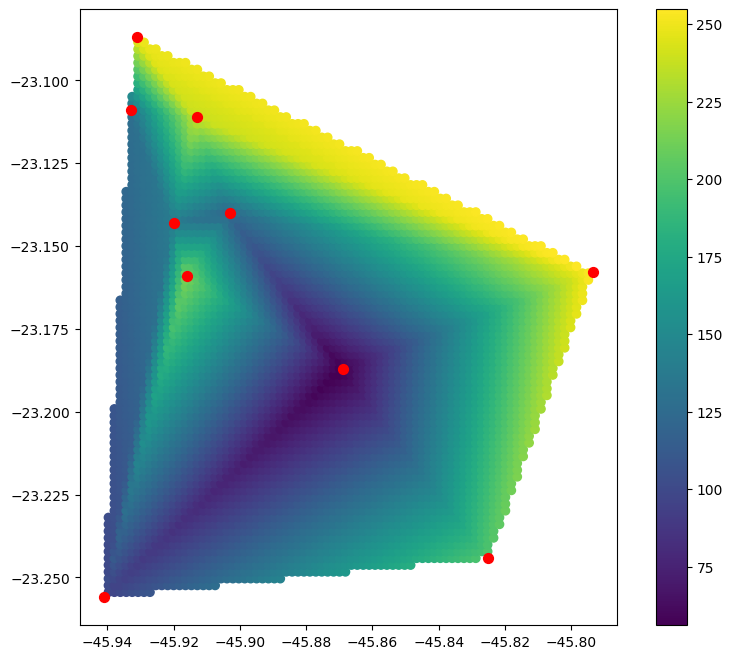

In [ ]:
df = pivot.copy()

# Define a expansão desejada (por exemplo, 10%)
expansion_factor = 0.1

# Calcula os limites expandidos para o grid
min_lon, max_lon = min(df['longitude']) - expansion_factor * (max(df['longitude']) - min(df['longitude'])), max(df['longitude']) + expansion_factor * (max(df['longitude']) - min(df['longitude']))
min_lat, max_lat = min(df['latitude']) - expansion_factor * (max(df['latitude']) - min(df['latitude'])), max(df['latitude']) + expansion_factor * (max(df['latitude']) - min(df['latitude']))

# Configuração do grid para a interpolação
grid_lon = np.linspace(min_lon, max_lon, num=100)
grid_lat = np.linspace(min_lat, max_lat, num=100)
grid_x, grid_y = np.meshgrid(grid_lon, grid_lat)

# Gera os pontos do grid
grid_points = np.column_stack((grid_x.flatten(), grid_y.flatten()))

# Realiza a interpolação por splines cúbicas
grid_result = griddata((df['longitude'], df['latitude']), df['data'], grid_points, method='linear')

# Cria um DataFrame com os resultados da interpolação
result_data = {
    'longitude': grid_x.flatten(),
    'latitude': grid_y.flatten(),
    'value': grid_result.flatten()
}

result_spl = pd.DataFrame(result_data).copy()

# Cria um GeoDataFrame a partir do DataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']))

# Cria um GeoDataFrame a partir do DataFrame de resultados
result_gdf = gpd.GeoDataFrame(result_spl, geometry=gpd.points_from_xy(result_spl['longitude'], result_spl['latitude']))

# Plota os resultados
fig, ax = plt.subplots(figsize=(10, 8))
result_gdf.plot(ax=ax, column='value', cmap='viridis', legend=True, label='Interpolação por Splines')
gdf.plot(ax=ax, color='red', markersize=50, label='Dados Observados')
plt.show()


### Preencher

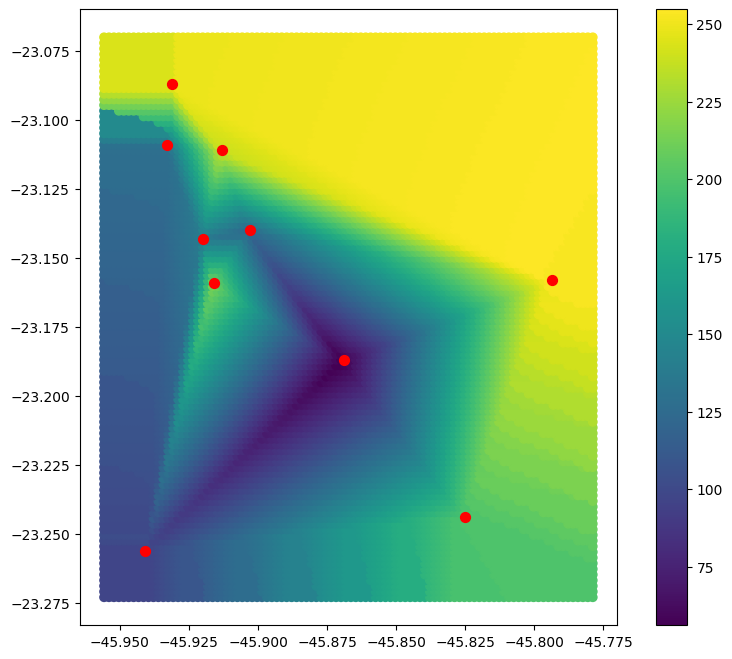

In [ ]:
# Função para encontrar a localização mais próxima
def encontrar_localizacao_mais_proxima(row, df_valores_existentes):
    # Coordenadas da localização atual
    lat, lon = row['latitude'], row['longitude']

    # Coordenadas das localizações disponíveis no DataFrame df_valores_existentes
    coords_valores_existentes = df_valores_existentes[['latitude', 'longitude']].values

    # Calcula as distâncias entre a localização atual e as localizações disponíveis
    distancias = cdist([(lat, lon)], coords_valores_existentes)[0]

    # Encontra o índice da localização mais próxima
    indice_localizacao_mais_proxima = np.argmin(distancias)

    # Obtém o valor da coluna 'value' da localização mais próxima
    valor_mais_proximo = df_valores_existentes.iloc[indice_localizacao_mais_proxima]['value']

    return valor_mais_proximo

# Cria um DataFrame apenas com os valores existentes
df_valores_existentes = result_spl.dropna(subset=['value'])

# Encontrar os índices dos valores NaN
indices_nan = result_spl[result_spl['value'].isna()].index

# Preencher os valores NaN com os valores mais próximos do DataFrame df_valores_existentes
result_spl.loc[indices_nan, 'value'] = result_spl.loc[indices_nan].apply(encontrar_localizacao_mais_proxima, df_valores_existentes=df_valores_existentes, axis=1)

# Cria um GeoDataFrame a partir do DataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']))

# Cria um GeoDataFrame a partir do DataFrame de resultados
result_gdf = gpd.GeoDataFrame(result_spl, geometry=gpd.points_from_xy(result_spl['longitude'], result_spl['latitude']))

# Plota os resultados
fig, ax = plt.subplots(figsize=(10, 8))
result_gdf.plot(ax=ax, column='value', cmap='viridis', legend=True, label='Interpolação por Splines')
gdf.plot(ax=ax, color='red', markersize=50, label='Dados Observados')
plt.show()



### Multiplos métodos

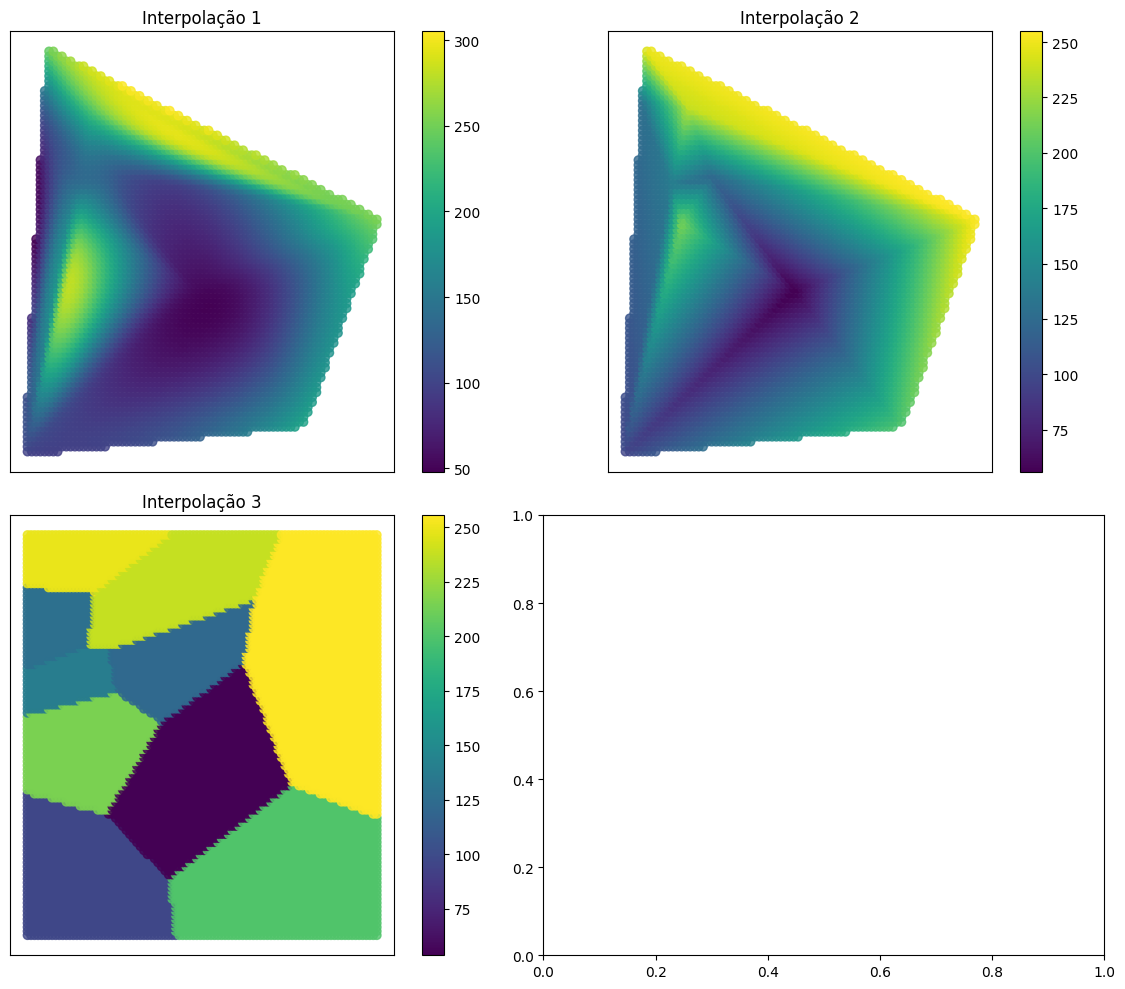

In [ ]:
# Seu conjunto de dados (substitua por seus próprios dados)
df = pivot.copy()

# Define a expansão desejada (por exemplo, 10%)
expansion_factor = 0.1

# Calcula os limites expandidos para o grid
min_lon, max_lon = min(df['longitude']) - expansion_factor * (max(df['longitude']) - min(df['longitude'])), max(df['longitude']) + expansion_factor * (max(df['longitude']) - min(df['longitude']))
min_lat, max_lat = min(df['latitude']) - expansion_factor * (max(df['latitude']) - min(df['latitude'])), max(df['latitude']) + expansion_factor * (max(df['latitude']) - min(df['latitude']))

# Configuração do grid para a interpolação
grid_lon = np.linspace(min_lon, max_lon, num=100)
grid_lat = np.linspace(min_lat, max_lat, num=100)
grid_x, grid_y = np.meshgrid(grid_lon, grid_lat)

# Lista de parâmetros para testar
parameters = [{'method': 'cubic'},
              {'method': 'linear'},
              {'method': 'nearest'}]

# Lista para armazenar os resultados
results = []

# Loop sobre os parâmetros
for param in parameters:
    # Realiza a interpolação com os parâmetros especificados
    grid_result = griddata((df['longitude'], df['latitude']), df['data'], (grid_x, grid_y), **param)

    # Cria um DataFrame com os resultados da interpolação
    result_data = {
        'longitude': grid_x.flatten(),
        'latitude': grid_y.flatten(),
        'value': grid_result.flatten()
    }

    # Adiciona os parâmetros ao DataFrame result_data
    result_data.update(param)

    results.append(pd.DataFrame(result_data))

# Plota os resultados
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, result in enumerate(results):
    ax = axes[i//2, i%2]
    gdf = gpd.GeoDataFrame(result, geometry=gpd.points_from_xy(result['longitude'], result['latitude']))
    gdf.plot(ax=ax, column='value', cmap='viridis', legend=True, label=f"Interp. {i+1}", alpha=0.8)
    ax.set_title(f"Interpolação {i+1}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()


In [ ]:
# Função para encontrar a localização mais próxima com valor maior que zero
def encontrar_localizacao_mais_proxima(row, df_valores_existentes):
    # Coordenadas da localização atual
    lat, lon = row['latitude'], row['longitude']

    # Coordenadas das localizações disponíveis no DataFrame df_valores_existentes
    coords_valores_existentes = df_valores_existentes[['latitude', 'longitude']].values

    # Calcula as distâncias entre a localização atual e as localizações disponíveis
    distancias = cdist([(lat, lon)], coords_valores_existentes)[0]

    # Encontra os índices dos valores maiores que zero
    indices_valores_maiores_que_zero = df_valores_existentes[df_valores_existentes['value'] > 0].index

    # Encontra o índice da localização mais próxima com valor maior que zero
    indices_mais_proximos_maiores_que_zero = [i for i in indices_valores_maiores_que_zero if i in indices_valores_maiores_que_zero]

    # Se houver índices de valores maiores que zero
    if indices_mais_proximos_maiores_que_zero:
        # Calcula as distâncias apenas para esses índices
        distancias = cdist([(lat, lon)], coords_valores_existentes[indices_mais_proximos_maiores_que_zero])[0]
        # Encontra o índice da localização mais próxima
        indice_localizacao_mais_proxima = indices_mais_proximos_maiores_que_zero[np.argmin(distancias)]
        # Obtém o valor da coluna 'value' da localização mais próxima
        valor_mais_proximo = df_valores_existentes.loc[indice_localizacao_mais_proxima, 'value']
    else:
        # Se não houver valores maiores que zero, retorna NaN
        valor_mais_proximo = np.nan

    return valor_mais_proximo


# Loop para preencher os valores NaN em cada DataFrame dentro de results
for i, result_df in enumerate(results):
    # Cria um DataFrame apenas com os valores existentes
    df_valores_existentes = result_df.dropna(subset=['value'])

    # Encontrar os índices dos valores NaN e valores iguais a zero
    indices_nan_or_zero = result_df[result_df['value'].isna() | (result_df['value'] == 0)].index

    # Preencher os valores NaN com os valores mais próximos do DataFrame df_valores_existentes
    result_df.loc[indices_nan_or_zero, 'value'] = result_df.loc[indices_nan_or_zero].apply(
        encontrar_localizacao_mais_proxima,
        df_valores_existentes=df_valores_existentes, axis=1)

    # Atualiza o DataFrame no array de resultados
    results[i] = result_df

# Plota os resultados
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, result_df in enumerate(results):
    ax = axes[i//2, i%2]
    gdf = gpd.GeoDataFrame(result_df, geometry=gpd.points_from_xy(result_df['longitude'], result_df['latitude']))
    gdf.plot(ax=ax, column='value', cmap='viridis', legend=True, label=f"Interp. {i+1}", alpha=0.8)
    ax.set_title(f"Interpolação {i+1}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()


IndexError: index 4611 is out of bounds for axis 0 with size 4596

In [ ]:
# Lista para armazenar os resultados
resultados = []

# Função para encontrar a localização mais próxima
def encontrar_localizacao_mais_proxima(row, intepolation):
    # Coordenadas da localização atual
    lat, lon = row['latitude'], row['longitude']

    # Coordenadas das localizações disponíveis no intepolation_IDW
    coords_intepolation_IDW = intepolation[['latitude', 'longitude']].values

    # Calcula as distâncias entre a localização atual e as localizações disponíveis
    distancias = cdist([(lat, lon)], coords_intepolation_IDW)[0]

    # Encontra o índice da localização mais próxima
    indice_localizacao_mais_proxima = np.argmin(distancias)

    # Obtém o valor da coluna 'value' da localização mais próxima
    valor_mais_proximo = intepolation.iloc[indice_localizacao_mais_proxima]['value']

    return valor_mais_proximo



# Avaliação dos resultados para cada método de interpolação
for i, result in enumerate(results, start=1):
    # Adiciona a coluna de previsão ao DataFrame novas_loc para cada método
    novas_loc[f'previsao_{i}'] = novas_loc.apply(encontrar_localizacao_mais_proxima, axis=1, intepolation=result)

    # Valores observados e previstos
    observados = novas_loc['Total'].values
    previstos = novas_loc[f'previsao_{i}'].values

    # Cálculo das métricas de erro
    mae = mean_absolute_error(observados, previstos)
    mse = mean_squared_error(observados, previstos)
    rmse = np.sqrt(mse)
    mape = calculate_mape(observados, previstos)

    # Armazena os resultados nesta iteração
    resultados.append({
        'Método': result['method'].unique(),
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape
    })

# Exibe os resultados
for resultado in resultados:
    print(f"{resultado['Método']}")
    print(f'MAE: {resultado["MAE"]}')
    print(f'MSE: {resultado["MSE"]}')
    print(f'RMSE: {resultado["RMSE"]}')
    print(f"MAPE: {resultado['MAPE']}%\n")


# Resultados

In [ ]:
# Função para encontrar a localização mais próxima
def encontrar_localizacao_mais_proxima(row, intepolation):
    # Coordenadas da localização atual
    lat, lon = row['latitude'], row['longitude']

    # Coordenadas das localizações disponíveis no intepolation_IDW
    coords_intepolation_IDW = intepolation[['latitude', 'longitude']].values

    # Calcula as distâncias entre a localização atual e as localizações disponíveis
    distancias = cdist([(lat, lon)], coords_intepolation_IDW)[0]

    # Encontra o índice da localização mais próxima
    indice_localizacao_mais_proxima = np.argmin(distancias)

    # Obtém o valor da coluna 'value' da localização mais próxima
    valor_mais_proximo = intepolation.iloc[indice_localizacao_mais_proxima]['value']

    return valor_mais_proximo

# Adiciona a coluna 'previsao_IDW' ao DataFrame novas_loc
novas_loc['previsao_IDW'] = novas_loc.apply(encontrar_localizacao_mais_proxima, axis=1, intepolation=intepolation_IDW)
novas_loc['previsao_krg'] = novas_loc.apply(encontrar_localizacao_mais_proxima, axis=1, intepolation=result_krg)
novas_loc['previsao_spl'] = novas_loc.apply(encontrar_localizacao_mais_proxima, axis=1, intepolation=result_spl)

# Exibe o DataFrame atualizado
print(novas_loc)


                      nome  latitude  longitude  Total  previsao_IDW  \
0             Rio Comprido -23.25859  -45.94240  345.6     98.092113   
1                  Capuava -23.28499  -45.83325  140.7    183.359045   
2                Vila Nair -23.21662  -45.88589  200.1    134.073728   
3                São Bento -23.22675  -45.87754  211.5    142.318072   
4        Campo dos Alemães -23.27519  -45.90070  137.7    153.100904   
5           Jardim Oriente -23.23828  -45.89977  319.1    146.656189   
6          Sítio Bom Jesus -23.21269  -45.84754  205.5    146.447043   
7           Jardim do Lago -23.24058  -45.84127  219.0    187.735570   
8      Recanto dos Tamoios -23.27297  -45.79862  123.0    178.789197   
9          Vila Corintinha -23.18741  -45.86531  127.2     57.686182   
10     Jardim Nova América -23.19280  -45.90128  120.9    144.042743   
11   Jardim das Indústrias -23.22037  -45.92163  149.7    147.481667   
12                 Cambucá -23.20654  -45.75868  174.6    185.80

In [ ]:
novas_loc = novas_loc[novas_loc['Total'] <= novas_loc['previsao_IDW'].max()]


novas_loc = novas_loc.reset_index(drop=True)
novas_loc

,nome,latitude,longitude,Total,previsao_IDW,previsao_krg,previsao_spl
0,Capuava,-23.28499,-45.83325,140.7,183.359045,182.447895,192.795029
1,Vila Nair,-23.21662,-45.88589,200.1,134.073728,124.450668,88.881282
2,São Bento,-23.22675,-45.87754,211.5,142.318072,132.065228,112.756017
3,Campo dos Alemães,-23.27519,-45.90070,137.7,153.100904,145.235678,126.700290
4,Sítio Bom Jesus,-23.21269,-45.84754,205.5,146.447043,142.768740,127.104205
5,Jardim do Lago,-23.24058,-45.84127,219.0,187.735570,175.533922,176.072051
6,Recanto dos Tamoios,-23.27297,-45.79862,123.0,178.789197,186.917824,198.937833
7,Vila Corintinha,-23.18741,-45.86531,127.2,57.686182,69.724786,66.174805
8,Jardim Nova América,-23.19280,-45.90128,120.9,144.042743,135.540473,120.568110
9,Jardim das Indústrias,-23.22037,-45.92163,149.7,147.481667,137.063675,118.215698


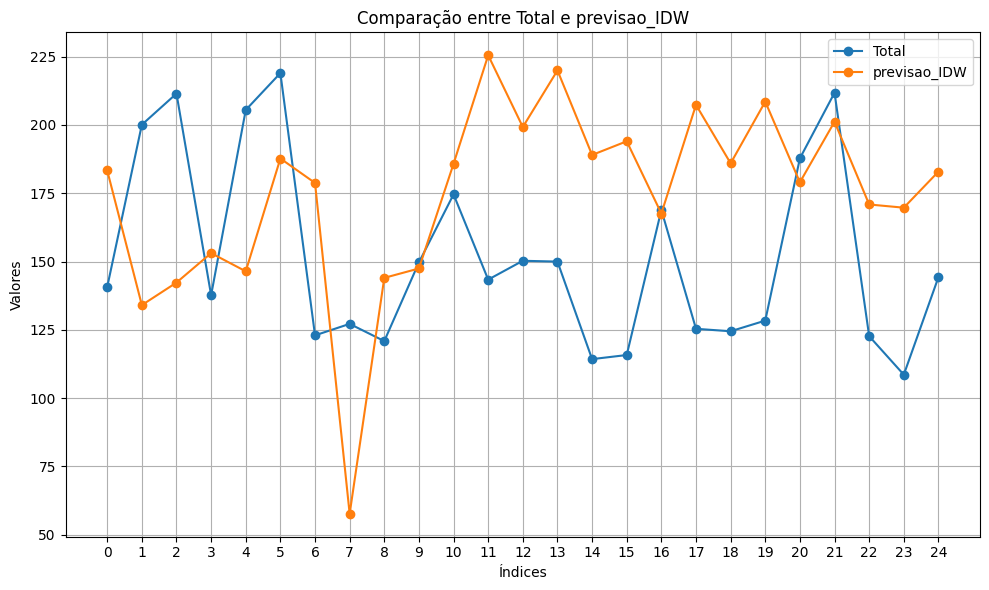

In [ ]:
novas_loc = novas_loc.reset_index(drop=True)

# Definir o índice para ser usado no gráfico
indices = novas_loc.index

# Plotar as colunas Total e previsao_IDW em um gráfico de linhas
plt.figure(figsize=(10, 6))
plt.plot(indices, novas_loc['Total'], marker='o', label='Total')
plt.plot(indices, novas_loc['previsao_IDW'], marker='o', label='previsao_IDW')

# Adicionar rótulos e títulos
plt.xlabel('Índices')
plt.ylabel('Valores')
plt.title('Comparação entre Total e previsao_IDW')
plt.xticks(indices)  # Ajustar a posição dos ticks no eixo x
plt.legend()  # Adicionar a legenda

# Exibir o gráfico
plt.grid(True)  # Adicionar grade
plt.tight_layout()  # Ajustar layout para evitar cortes
plt.show()

In [ ]:
#Valores observados e previstos
observados = novas_loc['Total'].values
previstos_IDW = novas_loc['previsao_IDW'].values
previstos_krg = novas_loc['previsao_krg'].values
previstos_spl = novas_loc['previsao_spl'].values

# Cálculo do MAE
mae_IDW = mean_absolute_error(observados, previstos_IDW)
mae_krg = mean_absolute_error(observados, previstos_krg)
mae_spl = mean_absolute_error(observados, previstos_spl)
# Cálculo do MSE
mse_IDW = mean_squared_error(observados, previstos_IDW)
mse_krg = mean_squared_error(observados, previstos_krg)
mse_spl = mean_squared_error(observados, previstos_spl)
# Cálculo do RMSE
rmse_IDW = np.sqrt(mse_IDW)
rmse_krg = np.sqrt(mse_krg)
rmse_spl = np.sqrt(mse_spl)

# Cálculo do mape
def calculate_mape(y_true, y_pred):
    # Garante que os arrays tenham o mesmo comprimento
    assert len(y_true) == len(y_pred), "Os arrays devem ter o mesmo comprimento"

    # Calcula o MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.abs(y_true))) * 100

    return mape

# Valor real
y_true_idw = np.array(novas_loc['Total'].values)  # Substitua pelos seus valores reais

# Não foi utilizado x_pred pois eu usei os valores direto
mape_IDW = calculate_mape(np.array(novas_loc['Total'].values), np.array(novas_loc['previsao_IDW'].values))
mape_krg = calculate_mape(np.array(novas_loc['Total'].values), np.array(novas_loc['previsao_krg'].values))
mape_spl = calculate_mape(np.array(novas_loc['Total'].values), np.array(novas_loc['previsao_spl'].values))

print("RESULTADO IDW")
print(f'MAE: {mae_IDW}')
print(f'MSE: {mse_IDW}')
print(f'RMSE: {rmse_IDW}')
print(f"MAPE: {mape_IDW}%")
print()
print("RESULTADO Krigagem")
print(f'MAE: {mae_krg}')
print(f'MSE: {mse_krg}')
print(f'RMSE: {rmse_krg}')
print(f"MAPE: {mape_krg}%")
print()
print("RESULTADO Splines")
print(f'MAE: {mae_spl}')
print(f'MSE: {mse_spl}')
print(f'RMSE: {rmse_spl}')
print(f"MAPE: {mape_spl}%")
print()


RESULTADO IDW
MAE: 47.66889019565317
MSE: 2987.511373784
RMSE: 54.658131817543854
MAPE: 34.26683419664949%

RESULTADO Krigagem
MAE: 51.339933781120045
MSE: 3433.567951964073
RMSE: 58.596654784757746
MAPE: 36.52563293492437%

RESULTADO Splines
MAE: 67.59392100021473
MSE: 6069.449156740089
RMSE: 77.90666952668487
MAPE: 46.50021829444118%



In [ ]:
print(novas_loc['previsao_IDW'].max())
print(novas_loc['previsao_krg'].max())
print(novas_loc['previsao_spl'].max())

225.52488897238305
227.14408908714296
252.8059152752056


In [ ]:
# Cria um mapa com a localização de São José dos Campos
mapa = folium.Map(location=[-23.1791, -45.8872], zoom_start=10)

# Adiciona um círculo vermelho para cada localização, com o tamanho proporcional à média de valores
for lat, lon, val in zip(novas_loc['latitude'], novas_loc['longitude'], novas_loc['previsao_IDW']):
  folium.CircleMarker(location=[lat, lon], radius=val/30, color='blue', fill=True).add_to(mapa)

# Adiciona um círculo azul para cada localização, com o tamanho proporcional à média de valores
for lat, lon, val in zip(novas_loc['latitude'], novas_loc['longitude'], novas_loc['Total']):
  folium.CircleMarker(location=[lat, lon], radius=val/30, color='yellow', fill=True).add_to(mapa)

# Mostra o mapa
mapa

# Comparação apenas com 2024

## Dividir dataframe

In [ ]:
# Defina a proporção desejada
proporcao_treino = 0.67  # 2/3

# Embaralhe as linhas do DataFrame
novas_loc_aleatorio = novas_loc.sample(frac=1, random_state=42)  # Use um random_state para garantir reprodutibilidade
#novas_loc_aleatorio = novas_loc.sample(frac=1)  # Use um random_state para garantir reprodutibilidade

# Número de linhas para treino
num_linhas_treino = int(len(novas_loc_aleatorio) * proporcao_treino)

# Divida o DataFrame em treino e teste
novas_loc_treino = novas_loc_aleatorio[:num_linhas_treino].copy()
novas_loc_teste = novas_loc_aleatorio[num_linhas_treino:].copy()

# Tamanho
print(f'Tamanho do DataFrame de Treino: {len(novas_loc_treino)}')
print(f'Tamanho do DataFrame de Teste: {len(novas_loc_teste)}')


Tamanho do DataFrame de Treino: 23
Tamanho do DataFrame de Teste: 12


## Interpolation Methods 2024

In [ ]:
# Define a função de criar um grid de novas localizações
def NovasLocalizacoes(df_t, n, expand):
  # Calcula os limites das localizações existentes em latitude e longitude
  lat_min = df_t['latitude'].min()
  lat_max = df_t['latitude'].max()
  lon_min = df_t['longitude'].min()
  lon_max = df_t['longitude'].max()
  # Expande os limites de acordo com o valor de expand
  lat_range = lat_max - lat_min
  lon_range = lon_max - lon_min
  lat_min = lat_min - expand * lat_range
  lat_max = lat_max + expand * lat_range
  lon_min = lon_min - expand * lon_range
  lon_max = lon_max + expand * lon_range
  # Cria n novas localizações geográficas em cada direção, formando um grid quadrado
  new_lats = np.linspace(lat_min, lat_max, n)
  new_lons = np.linspace(lon_min, lon_max, n)
  new_locs = np.meshgrid(new_lats, new_lons)
  # Cria um dataframe com as novas localizações e os nomes baseados na posição do grid
  new_df = pd.DataFrame({
      'latitude': new_locs[0].ravel(),
      'longitude': new_locs[1].ravel()
  })
  new_df['nomeEstacao'] = 'Loc_' + (new_df.index // n + 1).astype(str) + 'x' + (new_df.index % n + 1).astype(str)
  # Retorna o dataframe com as novas localizações
  return new_df


### IDW

In [ ]:
intepolation_IDW_2024 = NovasLocalizacoes(novas_loc_treino, n=100, expand=0.1)

# Calcula a matriz de distâncias entre as localizações interpoladas e as existentes
delta_lat = intepolation_IDW_2024['latitude'].values[:, np.newaxis] - novas_loc_treino['latitude'].values
delta_lon = intepolation_IDW_2024['longitude'].values[:, np.newaxis] - novas_loc_treino['longitude'].values
distances = np.sqrt(delta_lat**2 + delta_lon**2)

# Aplica um limite superior às distâncias
#max_distance = 3  # Ajuste conforme necessário
#distances[distances > max_distance] = max_distance

# Calcula o inverso das distâncias elevadas a 2
inverted_distances = (distances)**2
inverted_distances = 1 / inverted_distances

# Normaliza os pesos para que a soma seja igual a 1
weights_sum = np.sum(inverted_distances, axis=1, keepdims=True)
normalized_weights = inverted_distances / weights_sum

# Calcula os novos valores usando operações vetorizadas
values = np.sum(normalized_weights * novas_loc_treino['Total'].values, axis=1)

# Adiciona os valores ao DataFrame
intepolation_IDW_2024['value'] = values
result_IDW = intepolation_IDW_2024.copy()

# Cria um GeoDataFrame a partir do DataFrame
gdf = gpd.GeoDataFrame(novas_loc_treino, geometry=gpd.points_from_xy(novas_loc_treino['longitude'], novas_loc_treino['latitude']))

result_gdf = gpd.GeoDataFrame(intepolation_IDW_2024,
                              geometry=gpd.points_from_xy(intepolation_IDW_2024['longitude'],
                                                          intepolation_IDW_2024['latitude']))

# Plota os resultados
fig, ax = plt.subplots(figsize=(10, 8))
result_gdf.plot(ax=ax, column='value', cmap='viridis', legend=True, label='Interpolação por IDW')
gdf.plot(ax=ax, color='red', markersize=50, label='Dados Observados')
plt.show()

NameError: name 'novas_loc_treino' is not defined

### Kriging

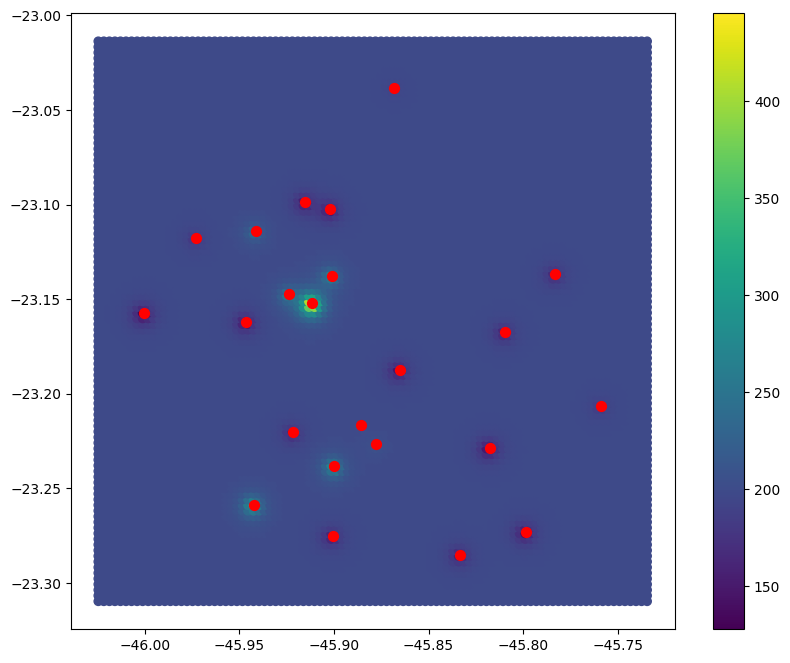

In [ ]:
# Substitua 'NovasLocalizacoes' pela função real que você está usando para criar o DataFrame df
df = novas_loc_treino.copy()

# Define a expansão desejada (por exemplo, 10%)
expansion_factor = 0.1

# Calcula os limites expandidos para o grid
min_lon, max_lon = min(df['longitude']) - expansion_factor * (max(df['longitude'])
- min(df['longitude'])), max(df['longitude']) + expansion_factor * (max(df['longitude']) - min(df['longitude']))
min_lat, max_lat = min(df['latitude']) - expansion_factor * (max(df['latitude'])
- min(df['latitude'])), max(df['latitude']) + expansion_factor * (max(df['latitude']) - min(df['latitude']))

# Configuração do grid para a krigagem
grid_lon = np.linspace(min_lon, max_lon, num=100)#Alterar para 10 se for usar no mapa
grid_lat = np.linspace(min_lat, max_lat, num=100)#Alterar para 10 se for usar no mapa
grid_x, grid_y = np.meshgrid(grid_lon, grid_lat)

# Parâmetros do modelo de variograma gaussiano
variogram_model = 'exponential'
sill = 100  # Ajuste conforme necessário
range_ = 0.01  # Ajuste conforme necessário
nugget = 0.0  # Ajuste conforme necessário

# Configuração do modelo de krigagem
model = OrdinaryKriging(
    df['longitude'],
    df['latitude'],
    df['Total'],
    variogram_model=variogram_model,
    variogram_parameters={'sill': sill, 'range': range_, 'nugget': nugget},
    verbose=False
)

# Realiza a krigagem no grid
kriged, ss = model.execute('grid', grid_lon, grid_lat)

# Cria um DataFrame com os resultados da krigagem
result_data = {
    'longitude': grid_x.flatten(),
    'latitude': grid_y.flatten(),
    'value': kriged.flatten()
}

result_krg = pd.DataFrame(result_data)

# Cria um GeoDataFrame a partir do DataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']))

# Cria um GeoDataFrame a partir do DataFrame de resultados
result_gdf = gpd.GeoDataFrame(result_krg, geometry=gpd.points_from_xy(result_krg['longitude'], result_krg['latitude']))

# Plota os resultados
fig, ax = plt.subplots(figsize=(10, 8))

result_gdf.plot(ax=ax, column='value', cmap='viridis', legend=True, label='Krigagem')
gdf.plot(ax=ax, color='red', markersize=50, label='Dados Observados')
plt.show()


### Splines

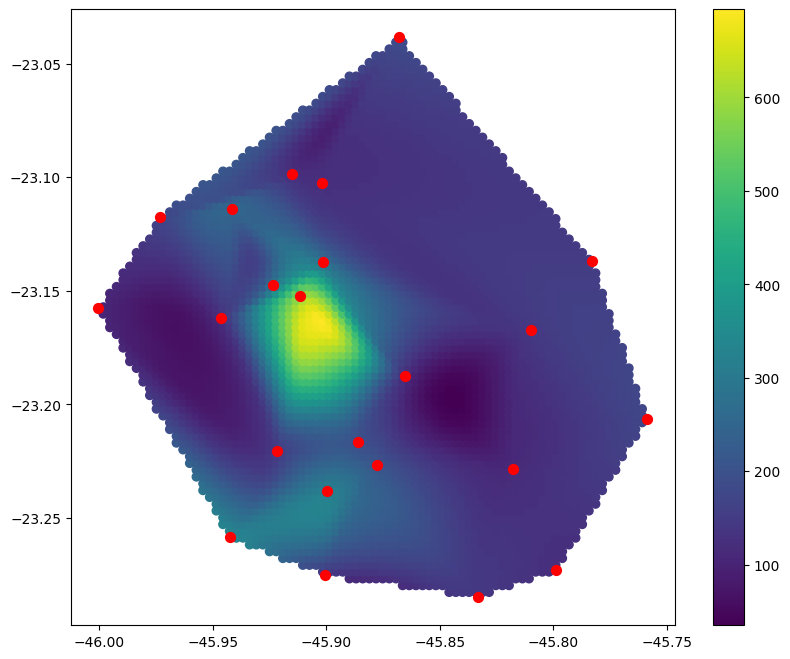

In [ ]:
df = novas_loc_treino.copy()

# Define a expansão desejada (por exemplo, 10%)
expansion_factor = 0.1

# Calcula os limites expandidos para o grid
min_lon, max_lon = min(df['longitude']) - expansion_factor * (max(df['longitude']) - min(df['longitude'])), max(df['longitude']) + expansion_factor * (max(df['longitude']) - min(df['longitude']))
min_lat, max_lat = min(df['latitude']) - expansion_factor * (max(df['latitude']) - min(df['latitude'])), max(df['latitude']) + expansion_factor * (max(df['latitude']) - min(df['latitude']))

# Configuração do grid para a interpolação
grid_lon = np.linspace(min_lon, max_lon, num=100)
grid_lat = np.linspace(min_lat, max_lat, num=100)
grid_x, grid_y = np.meshgrid(grid_lon, grid_lat)

# Gera os pontos do grid
grid_points = np.column_stack((grid_x.flatten(), grid_y.flatten()))

# Realiza a interpolação por splines cúbicas
grid_result = griddata((df['longitude'], df['latitude']), df['Total'], grid_points, method='cubic')

# Cria um DataFrame com os resultados da interpolação
result_data = {
    'longitude': grid_x.flatten(),
    'latitude': grid_y.flatten(),
    'value': grid_result.flatten()
}

result_spl = pd.DataFrame(result_data)

# Cria um GeoDataFrame a partir do DataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']))

# Cria um GeoDataFrame a partir do DataFrame de resultados
result_gdf = gpd.GeoDataFrame(result_spl, geometry=gpd.points_from_xy(result_spl['longitude'], result_spl['latitude']))

# Plota os resultados
fig, ax = plt.subplots(figsize=(10, 8))
result_gdf.plot(ax=ax, column='value', cmap='viridis', legend=True, label='Interpolação por Splines')
gdf.plot(ax=ax, color='red', markersize=50, label='Dados Observados')
plt.show()


#### Preencher

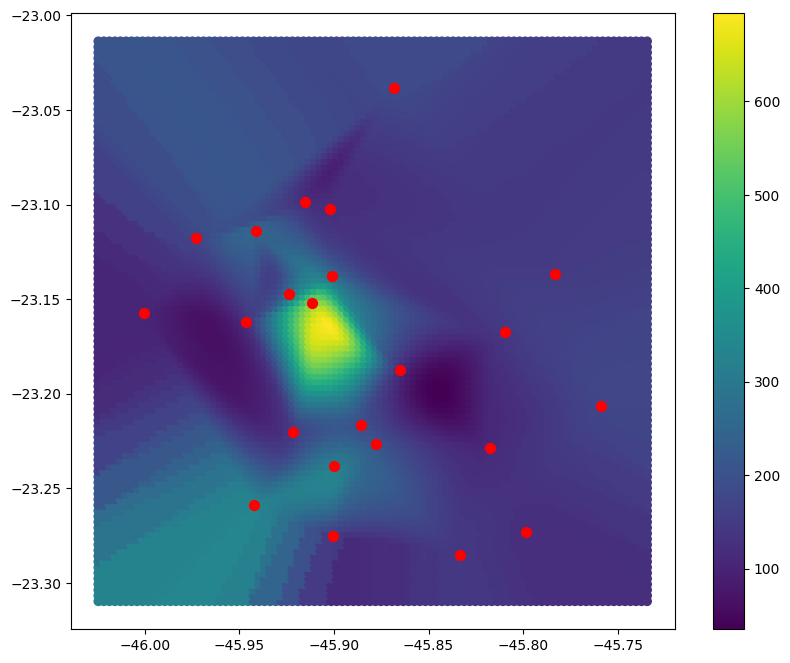

In [ ]:
# Função para encontrar a localização mais próxima
def encontrar_localizacao_mais_proxima(row, df_valores_existentes):
    # Coordenadas da localização atual
    lat, lon = row['latitude'], row['longitude']

    # Coordenadas das localizações disponíveis no DataFrame df_valores_existentes
    coords_valores_existentes = df_valores_existentes[['latitude', 'longitude']].values

    # Calcula as distâncias entre a localização atual e as localizações disponíveis
    distancias = cdist([(lat, lon)], coords_valores_existentes)[0]

    # Encontra o índice da localização mais próxima
    indice_localizacao_mais_proxima = np.argmin(distancias)

    # Obtém o valor da coluna 'value' da localização mais próxima
    valor_mais_proximo = df_valores_existentes.iloc[indice_localizacao_mais_proxima]['value']

    return valor_mais_proximo

# Cria um DataFrame apenas com os valores existentes
df_valores_existentes = result_spl.dropna(subset=['value'])

# Encontrar os índices dos valores NaN
indices_nan = result_spl[result_spl['value'].isna()].index

# Preencher os valores NaN com os valores mais próximos do DataFrame df_valores_existentes
result_spl.loc[indices_nan, 'value'] = result_spl.loc[indices_nan].apply(encontrar_localizacao_mais_proxima, df_valores_existentes=df_valores_existentes, axis=1)

# Cria um GeoDataFrame a partir do DataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']))

# Cria um GeoDataFrame a partir do DataFrame de resultados
result_gdf = gpd.GeoDataFrame(result_spl, geometry=gpd.points_from_xy(result_spl['longitude'], result_spl['latitude']))

# Plota os resultados
fig, ax = plt.subplots(figsize=(10, 8))
result_gdf.plot(ax=ax, column='value', cmap='viridis', legend=True, label='Interpolação por Splines')
gdf.plot(ax=ax, color='red', markersize=50, label='Dados Observados')
plt.show()



## Testes

In [ ]:
# Função para encontrar a localização mais próxima
def encontrar_localizacao_mais_proxima(row, intepolation):
    # Coordenadas da localização atual
    lat, lon = row['latitude'], row['longitude']
    novas_loc_treino
    # Coordenadas das localizações disponíveis no intepolation_IDW
    coords_intepolation = intepolation[['latitude', 'longitude']].values

    # Calcula as distâncias entre a localização atual e as localizações disponíveis
    distancias = cdist([(lat, lon)], coords_intepolation)[0]

    # Encontra o índice da localização mais próxima
    indice_localizacao_mais_proxima = np.argmin(distancias)

    # Obtém o valor da coluna 'value' da localização mais próxima
    valor_mais_proximo = intepolation.iloc[indice_localizacao_mais_proxima]['value']

    return valor_mais_proximo

# Adiciona as colunas de previsao ao DataFrame novas_loc
novas_loc_teste['previsao_IDW'] = novas_loc_teste.apply(encontrar_localizacao_mais_proxima, axis=1, intepolation=intepolation_IDW_2024)
novas_loc_teste['previsao_krg'] = novas_loc_teste.apply(encontrar_localizacao_mais_proxima, axis=1, intepolation=result_krg)
novas_loc_teste['previsao_spl'] = novas_loc_teste.apply(encontrar_localizacao_mais_proxima, axis=1, intepolation=result_spl)

# Exibe o DataFrame atualizado
print(novas_loc_teste)


                      nome  latitude  longitude  Total  previsao_krg  \
23                   Turvo -23.08646  -45.98205  115.8    198.787671   
31    São Francisco Xavier -22.91015  -45.95045  211.8    198.789146   
10     Jardim Nova América -23.19280  -45.90128  120.9    198.787755   
22        Águas de Canindú -23.13586  -45.89148  279.0    205.721868   
18               Dona Nega -23.11022  -45.93414  267.4    202.265215   
25       Fazenda Boa Vista -23.08948  -45.93000  262.8    198.539532   
6          Sítio Bom Jesus -23.21269  -45.84754  205.5    198.781367   
20   Mirante do Buquirinha -23.11164  -45.91978  248.1    197.771873   
34         Recanto do Vale -23.23149  -45.79330  144.3    198.739036   
7           Jardim do Lago -23.24058  -45.84127  219.0    198.749073   
14         Chácaras Araújo -23.18956  -45.79978  150.3    198.760039   
28           Pedra d'Dágua -23.09899  -45.88421  124.5    198.467123   

    previsao_1  previsao_IDW  previsao_spl  
23         NaN    

### Comparação
#### Erro Absoluto Médio (MAE):
A média das diferenças absolutas entre os valores observados e previstos. É fácil de entender, mas pode ser sensível a outliers.

\begin{equation}
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
\tag{1}
\end{equation}

####Erro Quadrático Médio (MSE):
A média das diferenças quadráticas entre os valores observados e previstos. Ele penaliza erros maiores mais fortemente.

\begin{equation}
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\tag{2}
\end{equation}

####Raiz do Erro Quadrático Médio (RMSE):
A raiz quadrada do MSE, dando uma medida do erro na mesma unidade dos dados originais.

\begin{equation}
\text{RMSE} = \sqrt{\text{MSE}}
\tag{3}
\end{equation}

#### Porcentagem média de erro (MAPE):

\begin{equation}
\text{MAPE} = \frac{100}{n} \sum_{i=1}^{n} \left|\frac{y_i - \hat{y}_i}{y_i}\right|
\tag{4}
\end{equation}


In [ ]:
#Valores observados e previstos
observados = novas_loc_teste['Total'].values
previstos_IDW = novas_loc_teste['previsao_IDW'].values
previstos_krg = novas_loc_teste['previsao_krg'].values
previstos_spl = novas_loc_teste['previsao_spl'].values

# Cálculo do MAE
mae_IDW = mean_absolute_error(observados, previstos_IDW)
mae_krg = mean_absolute_error(observados, previstos_krg)
mae_spl = mean_absolute_error(observados, previstos_spl)
# Cálculo do MSE
mse_IDW = mean_squared_error(observados, previstos_IDW)
mse_krg = mean_squared_error(observados, previstos_krg)
mse_spl = mean_squared_error(observados, previstos_spl)
# Cálculo do RMSE
rmse_IDW = np.sqrt(mse_IDW)
rmse_krg = np.sqrt(mse_krg)
rmse_spl = np.sqrt(mse_spl)

# Cálculo do mape
def calculate_mape(y_true, y_pred):
    # Garante que os arrays tenham o mesmo comprimento
    assert len(y_true) == len(y_pred), "Os arrays devem ter o mesmo comprimento"

    # Calcula o MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.abs(y_true))) * 100

    return mape

# Valor real
y_true_idw = np.array(novas_loc_teste['Total'].values)  # Valores reais

# Não foi utilizado x_pred pois eu usei os valores direto
mape_IDW = calculate_mape(y_true_idw, np.array(novas_loc_teste['previsao_IDW'].values))
mape_krg = calculate_mape(y_true_idw, np.array(novas_loc_teste['previsao_krg'].values))
mape_spl = calculate_mape(y_true_idw, np.array(novas_loc_teste['previsao_spl'].values))

### Resultados

In [ ]:
print("RESULTADO IDW")
print(f'MAE: {mae_IDW}')
print(f'MSE: {mse_IDW}')
print(f'RMSE: {rmse_IDW}')
print(f"MAPE: {mape_IDW}%")
print()
print("RESULTADO Krigagem")
print(f'MAE: {mae_krg}')
print(f'MSE: {mse_krg}')
print(f'RMSE: {rmse_krg}')
print(f"MAPE: {mape_krg}%")
print()
print("RESULTADO Splines")
print(f'MAE: {mae_spl}')
print(f'MSE: {mse_spl}')
print(f'RMSE: {rmse_spl}')
print(f"MAPE: {mape_spl}%")
print()


RESULTADO IDW
MAE: 43.88026428126881
MSE: 2911.550735015699
RMSE: 53.958787375326544
MAPE: 26.993111812809172%

RESULTADO Krigagem
MAE: 52.560295853314216
MSE: 3386.304208365553
RMSE: 58.19195999762814
MAPE: 31.62399639830043%

RESULTADO Splines
MAE: 70.34967572888364
MSE: 11643.138460877264
RMSE: 107.90337557684312
MAPE: 43.867610449463285%



## Mapa Janeiro de 2024

In [ ]:
# Cria um mapa com a localização de São José dos Campos
mapa = folium.Map(location=[-23.1791, -45.8872], zoom_start=10)

# Adiciona um círculo vermelho para cada localização, com o tamanho proporcional à média de valores
for lat, lon, val in zip(novas_loc_teste['latitude'], novas_loc_teste['longitude'], novas_loc_teste['previsao_IDW']):
  folium.CircleMarker(location=[lat, lon], radius=val/30, color='blue', fill=True).add_to(mapa)

# Adiciona um círculo azul para cada localização, com o tamanho proporcional à média de valores
for lat, lon, val in zip(novas_loc_teste['latitude'], novas_loc_teste['longitude'], novas_loc_teste['Total']):
  folium.CircleMarker(location=[lat, lon], radius=val/30, color='red', fill=True).add_to(mapa)

# Mostra o mapa
mapa

# Novos testes

In [ ]:
# Diretório onde estão os arquivos
dir_path = "/content/drive/My Drive/Projeto/SJC/2024/"

# Lista para armazenar os dataframes
dfs = []

# Verifica se o arquivo 'data.csv' existe
filepath = os.path.join(dir_path, 'data.csv')
if os.path.isfile(filepath):
    # Lê o arquivo 'data.csv'
    df = pd.read_csv(filepath, usecols=['nomeEstacao', 'latitude', 'longitude', 'datahora', 'valorMedida'], sep=';', decimal=',')

    # Converte a coluna 'datahora' para datetime
    df['datahora'] = pd.to_datetime(df['datahora'])

    # Converte a coluna valorMedida para float
    df['valorMedida'] = pd.to_numeric(df['valorMedida'])

    # Cria uma coluna 'localizacao' que combina a latitude e a longitude de cada estação pluviométrica
    df['localizacao'] = df['latitude'].astype(str) + ',' + df['longitude'].astype(str)

    # Cria uma coluna 'ano_mes' que combina o ano e o mês
    df['ano_mes'] = df['datahora'].dt.to_period('M')

    # Agrupa os dados por 'localizacao', 'ano_mes' e calcula a soma dos valores de medida
    df = df.groupby(['localizacao', 'ano_mes']).agg({'nomeEstacao': 'first', 'valorMedida': 'sum'}).reset_index()

    # Cria um dataframe 'localizacoes' que contém todas as localizações únicas e os nomes das estações associadas
    localizacoes = df.groupby('localizacao').agg({'nomeEstacao': lambda x: list(set(x))}).reset_index()

    # Cria uma coluna 'nomes' que concatena os nomes das estações que têm a mesma localização
    localizacoes['nomes'] = localizacoes['nomeEstacao'].apply(lambda x: ' / '.join(x))

    # Cria um dataframe 'pivot' que transforma os valores de 'ano_mes' em colunas e preenche os valores de medida
    pivot = df.pivot(index='localizacao', columns='ano_mes', values='valorMedida').reset_index()

    # Converte as colunas 'ano_mes' para strings sem caracteres especiais
    pivot.columns = pivot.columns.astype(str)
    pivot.columns = pivot.columns.str.replace('[^a-zA-Z0-9]', '_')  # Substitui caracteres especiais por underscore

    # Cria uma coluna 'nomes' que concatena os nomes das estações que têm a mesma localização
    pivot = pivot.merge(localizacoes[['localizacao', 'nomes']], on='localizacao', how='left')

    # Separa a coluna 'localizacao' em 'latitude' e 'longitude'
    pivot[['latitude', 'longitude']] = pivot['localizacao'].str.split(',', expand=True)

    # Converte as colunas 'latitude' e 'longitude' para float
    pivot['latitude'] = pivot['latitude'].astype(float)
    pivot['longitude'] = pivot['longitude'].astype(float)

    # Remove as colunas desnecessárias
    pivot = pivot.drop(columns=['localizacao'])

    # Reordena as colunas
    pivot = pivot[['nomes', 'latitude', 'longitude'] + [col for col in pivot.columns if col not in ['nomes', 'latitude', 'longitude']]]

    # Adiciona o dataframe resultante à lista
    dfs.append(pivot)

# Concatena os dataframes da lista
result_df = pd.concat(dfs, axis=0)

# Mostra o dataframe final
print(result_df)


                                    nomes   latitude  longitude  2024_01
0                       Chacara Boa Vista -23.087000   -45.9310   293.50
1                                 Freitas -23.109000   -45.9330   239.72
2                    Jardim Santa Matilde -23.140000   -45.9030    54.93
3                        Altos Vila Paiva -23.143000   -45.9200   291.94
4  Parque Tecnológico SJC (TESTES PLUVIO) -23.157954   -45.7935   133.80
5                 Jardim Altos de Santana -23.159000   -45.9160   249.86
6                          Jardim Jussara -23.187000   -45.8690   202.82
7                     Jardim São Leopoldo -23.244000   -45.8250   217.63
8                            Rio comprido -23.256000   -45.9410   313.20


<ipython-input-32-cda3c447c040>:39: FutureWarning: The default value of regex will change from True to False in a future version.
  pivot.columns = pivot.columns.str.replace('[^a-zA-Z0-9]', '_')  # Substitui caracteres especiais por underscore


In [ ]:
# Cria um mapa com a localização de São José dos Campos
mapa = folium.Map(location=[-23.1791, -45.8872], zoom_start=10)

# Adiciona um círculo azul para cada localização, com o tamanho proporcional à média de valores
for lat, lon, val in zip(novas_loc['latitude'], novas_loc['longitude'], novas_loc['Total']):
  folium.CircleMarker(location=[lat, lon], radius=val/30, color='red', fill=True).add_to(mapa)


# Adiciona um círculo vermelho para cada localização, com o tamanho proporcional à média de valores
for lat, lon, val in zip(result_df['latitude'], result_df['longitude'], result_df['2024_01']):
  folium.CircleMarker(location=[lat, lon], radius=val/30, color='blue', fill=True).add_to(mapa)


# Mostra o mapa
mapa

# Testes para artigo

In [ ]:
import pandas as pd
dataframe = pd.read_csv("Resultados.csv")

In [ ]:
dataframe

,nome,latitude,longitude,Total,previsao_krg,previsao_IDW,previsao_spl
0,Rio Comprido,-23.25859,-45.94240,345.6,169.674185,142.485743,96.716912
1,Capuava,-23.28499,-45.83325,140.7,169.674185,169.674185,192.795029
2,Vila Nair,-23.21662,-45.88589,200.1,169.674185,169.674185,88.881282
3,São Bento,-23.22675,-45.87754,211.5,169.674185,169.674185,112.756017
4,Campo dos Alemães,-23.27519,-45.90070,137.7,169.674185,169.674185,126.700290
5,Jardim Oriente,-23.23828,-45.89977,319.1,169.674185,169.674185,109.326116
6,Sítio Bom Jesus,-23.21269,-45.84754,205.5,169.674185,169.674185,127.104205
7,Jardim do Lago,-23.24058,-45.84127,219.0,169.674185,169.674185,176.072051
8,Recanto dos Tamoios,-23.27297,-45.79862,123.0,169.674185,169.674185,198.937833
9,Vila Corintinha,-23.18741,-45.86531,127.2,169.674185,142.193387,66.174805


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

novas_loc

#Valores observados e previstos
observados = novas_loc['Total'].values
previstos_IDW = novas_loc['previsao_IDW'].values
previstos_krg = novas_loc['previsao_krg'].values
previstos_spl = novas_loc['previsao_spl'].values

# Cálculo do MAE
mae_IDW = mean_absolute_error(observados, previstos_IDW)
mae_krg = mean_absolute_error(observados, previstos_krg)
mae_spl = mean_absolute_error(observados, previstos_spl)
# Cálculo do MSE
mse_IDW = mean_squared_error(observados, previstos_IDW)
mse_krg = mean_squared_error(observados, previstos_krg)
mse_spl = mean_squared_error(observados, previstos_spl)
# Cálculo do RMSE
rmse_IDW = np.sqrt(mse_IDW)
rmse_krg = np.sqrt(mse_krg)
rmse_spl = np.sqrt(mse_spl)

# Cálculo do mape
def calculate_mape(y_true, y_pred):
    # Garante que os arrays tenham o mesmo comprimento
    assert len(y_true) == len(y_pred), "Os arrays devem ter o mesmo comprimento"

    # Calcula o MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.abs(y_true))) * 100

    return mape

# Valor real
y_true_idw = np.array(novas_loc['Total'].values)  # Substitua pelos seus valores reais

# Não foi utilizado x_pred pois eu usei os valores direto
mape_IDW = calculate_mape(np.array(novas_loc['Total'].values), np.array(novas_loc['previsao_IDW'].values))
mape_krg = calculate_mape(np.array(novas_loc['Total'].values), np.array(novas_loc['previsao_krg'].values))
mape_spl = calculate_mape(np.array(novas_loc['Total'].values), np.array(novas_loc['previsao_spl'].values))

print("RESULTADO IDW")
print(f'MAE: {mae_IDW}')
print(f'MSE: {mse_IDW}')
print(f'RMSE: {rmse_IDW}')
print(f"MAPE: {mape_IDW}%")
print()
print("RESULTADO Krigagem")
print(f'MAE: {mae_krg}')
print(f'MSE: {mse_krg}')
print(f'RMSE: {rmse_krg}')
print(f"MAPE: {mape_krg}%")
print()
print("RESULTADO Splines")
print(f'MAE: {mae_spl}')
print(f'MSE: {mse_spl}')
print(f'RMSE: {rmse_spl}')
print(f"MAPE: {mape_spl}%")
print()


RESULTADO IDW
MAE: 69.57549132242639
MSE: 10638.957952712559
RMSE: 103.1453244345693
MAPE: 31.99910547479363%

RESULTADO Krigagem
MAE: 81.48191751652216
MSE: 12550.072713863885
RMSE: 112.02710704942749
MAPE: 39.43967021358933%

RESULTADO Splines
MAE: 94.2589858655067
MSE: 14710.878753203886
RMSE: 121.28841145469704
MAPE: 47.01071751731432%



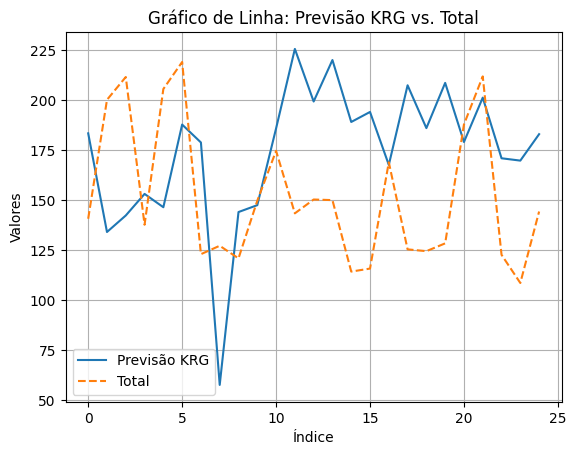

In [ ]:
# Gráfico de linha para previsão KRG
plt.plot(novas_loc.index, novas_loc['previsao_IDW'], label='Previsão KRG')
plt.plot(novas_loc.index, novas_loc['Total'], label='Total', linestyle='--')
plt.xlabel('Índice')
plt.ylabel('Valores')
plt.title('Gráfico de Linha: Previsão KRG vs. Total')
plt.legend()
plt.grid(True)
plt.show()


# Apenas 9

## Algoritmos função

In [ ]:
# Define a função de criar um grid de novas localizações
def NovasLocalizacoes(df_t, n, expand):
  # Calcula os limites das localizações existentes em latitude e longitude
  lat_min = df_t['latitude'].min()
  lat_max = df_t['latitude'].max()
  lon_min = df_t['longitude'].min()
  lon_max = df_t['longitude'].max()
  # Expande os limites de acordo com o valor de expand
  lat_range = lat_max - lat_min
  lon_range = lon_max - lon_min
  lat_min = lat_min - expand * lat_range
  lat_max = lat_max + expand * lat_range
  lon_min = lon_min - expand * lon_range
  lon_max = lon_max + expand * lon_range
  # Cria n novas localizações geográficas em cada direção, formando um grid quadrado
  new_lats = np.linspace(lat_min, lat_max, n)
  new_lons = np.linspace(lon_min, lon_max, n)
  new_locs = np.meshgrid(new_lats, new_lons)
  # Cria um dataframe com as novas localizações e os nomes baseados na posição do grid
  new_df = pd.DataFrame({
      'latitude': new_locs[0].ravel(),
      'longitude': new_locs[1].ravel()
  })
  new_df['nomeEstacao'] = 'Loc_' + (new_df.index // n + 1).astype(str) + 'x' + (new_df.index % n + 1).astype(str)
  # Retorna o dataframe com as novas localizações
  return new_df

def idw(treino):
  intepolation_IDW_2024 = NovasLocalizacoes(treino, n=100, expand=0.1)

  # Calcula a matriz de distâncias entre as localizações interpoladas e as existentes
  delta_lat = intepolation_IDW_2024['latitude'].values[:, np.newaxis] - treino['latitude'].values
  delta_lon = intepolation_IDW_2024['longitude'].values[:, np.newaxis] - treino['longitude'].values
  distances = np.sqrt(delta_lat**2 + delta_lon**2)

  # Aplica um limite superior às distâncias
  #max_distance = 3  # Ajuste conforme necessário
  #distances[distances > max_distance] = max_distance

  # Calcula o inverso das distâncias elevadas a 2
  inverted_distances = (distances)**2
  inverted_distances = 1 / inverted_distances

  # Normaliza os pesos para que a soma seja igual a 1
  weights_sum = np.sum(inverted_distances, axis=1, keepdims=True)
  normalized_weights = inverted_distances / weights_sum

  # Calcula os novos valores usando operações vetorizadas
  values = np.sum(normalized_weights * treino['media_j'].values, axis=1)

  # Adiciona os valores ao DataFrame
  intepolation_IDW_2024['value'] = values

  result_IDW = intepolation_IDW_2024.copy()

  return result_IDW

In [ ]:
def kriging(treino):

  # Substitua 'NovasLocalizacoes' pela função real que você está usando para criar o DataFrame df
  df = treino.copy()

  # Define a expansão desejada (por exemplo, 10%)
  expansion_factor = 0.1

  # Calcula os limites expandidos para o grid
  min_lon, max_lon = min(df['longitude']) - expansion_factor * (max(df['longitude'])
  - min(df['longitude'])), max(df['longitude']) + expansion_factor * (max(df['longitude']) - min(df['longitude']))
  min_lat, max_lat = min(df['latitude']) - expansion_factor * (max(df['latitude'])
  - min(df['latitude'])), max(df['latitude']) + expansion_factor * (max(df['latitude']) - min(df['latitude']))

  # Configuração do grid para a krigagem
  grid_lon = np.linspace(min_lon, max_lon, num=100)#Alterar para 10 se for usar no mapa
  grid_lat = np.linspace(min_lat, max_lat, num=100)#Alterar para 10 se for usar no mapa
  grid_x, grid_y = np.meshgrid(grid_lon, grid_lat)

  # Parâmetros do modelo de variograma gaussiano
  variogram_model = 'exponential'
  sill = 100  # Ajuste conforme necessário
  range_ = 0.01  # Ajuste conforme necessário
  nugget = 0.0  # Ajuste conforme necessário

  # Configuração do modelo de krigagem
  model = OrdinaryKriging(
      df['longitude'],
      df['latitude'],
      df['media_j'],
      variogram_model=variogram_model,
      variogram_parameters={'sill': sill, 'range': range_, 'nugget': nugget},
      verbose=False
  )

  # Realiza a krigagem no grid
  kriged, ss = model.execute('grid', grid_lon, grid_lat)

  # Cria um DataFrame com os resultados da krigagem
  result_data = {
      'longitude': grid_x.flatten(),
      'latitude': grid_y.flatten(),
      'value': kriged.flatten()
  }

  result_krg = pd.DataFrame(result_data)

  return result_krg


In [ ]:
def splines(treino):

  df = treino.copy()

  # Define a expansão desejada (por exemplo, 10%)
  expansion_factor = 0.1

  # Calcula os limites expandidos para o grid
  min_lon, max_lon = min(df['longitude']) - expansion_factor * (max(df['longitude']) - min(df['longitude'])), max(df['longitude']) + expansion_factor * (max(df['longitude']) - min(df['longitude']))
  min_lat, max_lat = min(df['latitude']) - expansion_factor * (max(df['latitude']) - min(df['latitude'])), max(df['latitude']) + expansion_factor * (max(df['latitude']) - min(df['latitude']))

  # Configuração do grid para a interpolação
  grid_lon = np.linspace(min_lon, max_lon, num=100)
  grid_lat = np.linspace(min_lat, max_lat, num=100)
  grid_x, grid_y = np.meshgrid(grid_lon, grid_lat)

  # Gera os pontos do grid
  grid_points = np.column_stack((grid_x.flatten(), grid_y.flatten()))

  # Realiza a interpolação por splines cúbicas
  grid_result = griddata((df['longitude'], df['latitude']), df['media_j'], grid_points, method='linear')

  # Cria um DataFrame com os resultados da interpolação
  result_data = {
      'longitude': grid_x.flatten(),
      'latitude': grid_y.flatten(),
      'value': grid_result.flatten()
  }

  result_spl = pd.DataFrame(result_data)

  return result_spl


In [ ]:

# Cálculo do mape
def calculate_mape(y_true, y_pred):
    # Garante que os arrays tenham o mesmo comprimento
    assert len(y_true) == len(y_pred), "Os arrays devem ter o mesmo comprimento"

    # Calcula o MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.abs(y_true))) * 100

    return mape

# Função para calcular as métricas de erro
def calcular_metricas(observados, previstos):
    mae = mean_absolute_error(observados, previstos)
    mse = mean_squared_error(observados, previstos)
    rmse = np.sqrt(mse)
    mape = calculate_mape(observados, previstos)
    return mae, mse, rmse, mape

# Função para encontrar a localização mais próxima com valor maior que zero
def encontrar_localizacao_mais_proxima(row, df_valores_existentes):
    valores_maiores_que_zero = df_valores_existentes[df_valores_existentes['value'] > 0]
    if valores_maiores_que_zero.empty:
        return np.nan
    distancias = cdist([(row['latitude'], row['longitude'])], valores_maiores_que_zero[['latitude', 'longitude']].values)[0]
    indice_mais_proximo = valores_maiores_que_zero.index[np.argmin(distancias)]
    return df_valores_existentes.loc[indice_mais_proximo, 'value']


In [ ]:
import pandas as pd
from itertools import combinations

df = pivot.loc[:, ["nomes", "latitude", "longitude", "media_j"]]

resultados_9_1 = {'IDW': [], 'Krigagem': [], 'Splines': []}
resultados_8_2 = {'IDW': [], 'Krigagem': [], 'Splines': []}


# Gerar todas as combinações possíveis de índices
indices = list(df.index)
combs_9_1 = list(combinations(indices, 9))
combs_8_2 = list(combinations(indices, 8))


# Função para dividir o dataframe com base nos índices
def split_dataframe(df, train_indices, test_indices):
    train_df = df.loc[train_indices]
    test_df = df.loc[test_indices]
    return train_df, test_df

# Separar o dataframe em 8 para treino e 1 para teste
for comb in combs_9_1:
    train_indices = np.array(comb)
    test_indices = list(set(indices) - set(comb))
    train_df, test_df = split_dataframe(df, train_indices, test_indices)

    resultado_idw = idw(train_df)
    resultado_krg = kriging(train_df)
    resultado_spl = splines(train_df)

    # Adicionar previsões ao DataFrame de teste
    test_df['previsao_IDW'] = test_df.apply(encontrar_localizacao_mais_proxima, axis=1, df_valores_existentes=resultado_idw)
    test_df['previsao_Krigagem'] = test_df.apply(encontrar_localizacao_mais_proxima, axis=1, df_valores_existentes=resultado_krg)
    test_df['previsao_Splines'] = test_df.apply(encontrar_localizacao_mais_proxima, axis=1, df_valores_existentes=resultado_spl)

    # Calcular métricas de erro
    for metodo, previsao_coluna in [('IDW', 'previsao_IDW'), ('Krigagem', 'previsao_Krigagem'), ('Splines', 'previsao_Splines')]:
        mae, mse, rmse, mape = calcular_metricas(test_df['media_j'].values, test_df[previsao_coluna].values)
        resultados_9_1[metodo].append([mae, mse, rmse, mape])


# Separar o dataframe em 7 para treino e 2 para teste
for comb in combs_8_2:
    train_indices = np.array(comb)
    test_indices = list(set(indices) - set(comb))
    train_df, test_df = split_dataframe(df, train_indices, test_indices)

    resultado_idw = idw(train_df)
    resultado_krg = kriging(train_df)
    resultado_spl = splines(train_df)

    # Adicionar previsões ao DataFrame de teste
    test_df['previsao_IDW'] = test_df.apply(encontrar_localizacao_mais_proxima, axis=1, df_valores_existentes=resultado_idw)
    test_df['previsao_Krigagem'] = test_df.apply(encontrar_localizacao_mais_proxima, axis=1, df_valores_existentes=resultado_krg)
    test_df['previsao_Splines'] = test_df.apply(encontrar_localizacao_mais_proxima, axis=1, df_valores_existentes=resultado_spl)

    # Calcular métricas de erro
    for metodo, previsao_coluna in [('IDW', 'previsao_IDW'), ('Krigagem', 'previsao_Krigagem'), ('Splines', 'previsao_Splines')]:
        mae, mse, rmse, mape = calcular_metricas(test_df['media_j'].values, test_df[previsao_coluna].values)
        resultados_8_2[metodo].append([mae, mse, rmse, mape])



In [ ]:
# Exibir resultados
for metodo, metricas in resultados_8_2.items():
    print(f'Resultados para {metodo}:')
    for i, (mae, mse, rmse, mape) in enumerate(metricas, start=1):
        print(f'  Execução {i}:')
        print(f'    MAE: {mae}')
        print(f'    MSE: {mse}')
        print(f'    RMSE: {rmse}')
        print(f'    MAPE: {mape}')

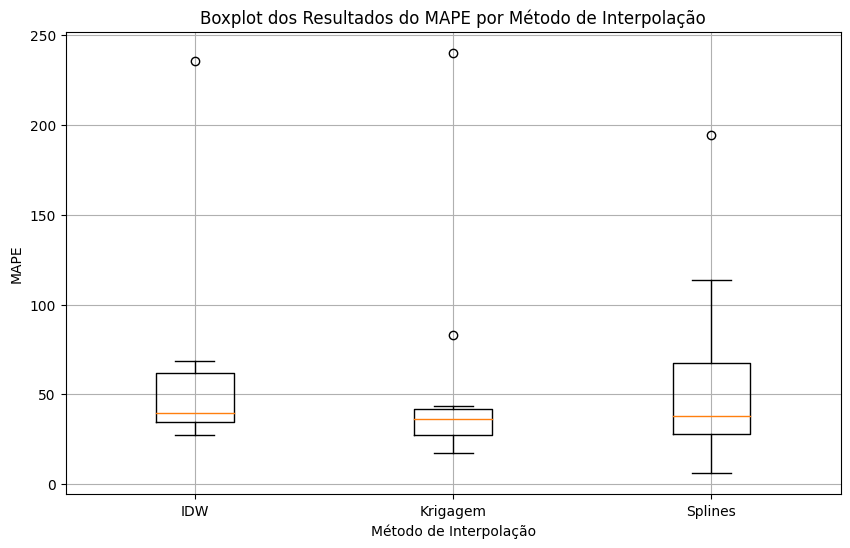

In [ ]:
import matplotlib.pyplot as plt

# Extrair os resultados do MAPE para cada método
mape_idw = [mape for mae, mse, rmse, mape in resultados_9_1['IDW']]
mape_krigagem = [mape for mae, mse, rmse, mape in resultados_9_1['Krigagem']]
mape_splines = [mape for mae, mse, rmse, mape in resultados_9_1['Splines']]

# Gerar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([mape_idw, mape_krigagem, mape_splines], labels=['IDW', 'Krigagem', 'Splines'])
plt.title('Boxplot dos Resultados do MAPE por Método de Interpolação')
plt.xlabel('Método de Interpolação')
plt.ylabel('MAPE')
plt.grid(True)
plt.show()


In [ ]:
pivot

,nomes,latitude,longitude,2019-01,2019-02,2019-03,2020-01,2020-02,2020-03,2021-01,...,2022-01,2022-02,2022-03,2023-01,2023-02,2023-03,media,media_j,media_f,media_m
0,Chacara Boa Vista,-23.087000,-45.931000,245.681667,245.681667,245.681667,236.150000,427.210000,131.200000,151.970000,...,453.400000,141.570000,172.240000,159.230000,413.830000,174.06,245.681667,249.286333,320.230333,167.528333
1,Freitas,-23.109000,-45.933000,125.287500,125.287500,236.440000,125.287500,125.287500,125.287500,172.110000,...,169.230000,72.660000,183.200000,170.450000,214.090000,31.80,125.287500,152.473000,149.499000,124.005500
2,Buquirinha,-23.111000,-45.913000,222.220000,335.940000,166.940000,241.700000,241.700000,241.700000,241.700000,...,241.700000,241.700000,241.700000,241.700000,241.700000,241.70,241.700000,237.804000,260.548000,226.748000
3,Jardim Santa Matilde,-23.140000,-45.903000,116.148333,5.940000,84.910000,116.148333,116.148333,116.148333,218.790000,...,158.790000,58.730000,158.720000,116.560000,34.600000,15.40,116.148333,145.287333,132.129667,94.257667
4,Altos Vila Paiva,-23.143000,-45.920000,207.900000,250.670000,166.620000,232.830000,279.320000,87.910000,113.850000,...,136.370000,167.721429,152.510000,167.721429,314.180000,109.49,167.721429,171.734286,242.228286,122.746000
5,Jardim Altos de Santana,-23.159000,-45.916000,233.550000,247.400000,197.060000,234.720000,286.080000,91.530000,243.930000,...,135.130000,96.300000,146.440000,228.820000,349.880000,111.76,207.919333,215.230000,281.980000,126.548000
6,Jardim Jussara / Jardim Juçara,-23.187000,-45.869000,2.600000,13.040000,73.177692,34.660000,2.800000,4.600000,73.177692,...,73.177692,73.177692,145.300000,158.100000,415.050000,137.71,73.177692,68.343077,115.449077,79.487538
7,Jardim São Leopoldo,-23.244000,-45.825000,208.420000,292.590000,201.700000,218.420000,323.800000,63.220000,171.060000,...,225.280714,625.830000,158.650000,178.410000,316.470000,132.58,225.280714,200.318143,339.988000,135.536000
8,Rio comprido,-23.256000,-45.941000,93.720000,101.028667,101.028667,65.800000,42.190000,101.028667,2.400000,...,207.780000,138.340000,244.470000,115.630000,351.270000,188.67,101.028667,97.066000,146.771467,139.911467
9,Parque tecnológico,-23.157943,-45.793501,255.666667,255.666667,255.666667,255.666667,255.666667,255.666667,255.666667,...,255.666667,255.666667,255.666667,255.666667,364.333333,147.00,255.666667,255.666667,277.400000,233.933333


# 7

In [ ]:

var_m = 'media_j'
# Cálculo do mape
def calculate_mape(y_true, y_pred):
    # Garante que os arrays tenham o mesmo comprimento
    assert len(y_true) == len(y_pred), "Os arrays devem ter o mesmo comprimento"

    # Calcula o MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.abs(y_true))) * 100

    return mape

# Função para calcular as métricas de erro
def calcular_metricas(observados, previstos):
    mae = mean_absolute_error(observados, previstos)
    mse = mean_squared_error(observados, previstos)
    rmse = np.sqrt(mse)
    mape = calculate_mape(observados, previstos)
    return mae, mse, rmse, mape

def idw(treino, teste):
  # Calcula a matriz de distâncias entre as localizações interpoladas e as existentes
  delta_lat = teste['latitude'].values[:, np.newaxis] - treino['latitude'].values
  delta_lon = teste['longitude'].values[:, np.newaxis] - treino['longitude'].values
  distances = np.sqrt(delta_lat**2 + delta_lon**2)

  # Calcula o inverso das distâncias elevadas a 2
  inverted_distances = (distances)**2
  inverted_distances = 1 / inverted_distances

  # Normaliza os pesos para que a soma seja igual a 1
  weights_sum = np.sum(inverted_distances, axis=1, keepdims=True)
  normalized_weights = inverted_distances / weights_sum

  # Calcula os novos valores usando operações vetorizadas
  values = np.sum(normalized_weights * treino['Total'].values, axis=1)

  result_IDW = pd.DataFrame({
        'latitude': teste['latitude'],
        'longitude': teste['longitude'],
        'value': values
  })

  return result_IDW['value']

def kriging(treino, teste):
    # Configuração do modelo de variograma
    variogram_model = 'exponential'
    sill = 100  # Ajuste conforme necessário
    range_ = 0.5  # Ajuste conforme necessário
    nugget = 0.0  # Ajuste conforme necessário

    # Configuração do modelo de krigagem
    model = OrdinaryKriging(
        treino['longitude'],
        treino['latitude'],
        treino['Total'],
        variogram_model=variogram_model,
        variogram_parameters={'sill': sill, 'range': range_, 'nugget': nugget},
        verbose=False
    )

    # Realiza a krigagem nas novas localizações do dataframe de teste
    kriged, _ = model.execute('points', teste['longitude'], teste['latitude'])

    # Cria um DataFrame com os resultados da krigagem
    result_krg = pd.DataFrame({
        'latitude': teste['latitude'],
        'longitude': teste['longitude'],
        'value': kriged.flatten()
    })

    return result_krg['value']

def splines(treino, teste):
    # Extrai as colunas necessárias do dataframe de treino
    points = treino[['latitude', 'longitude']].values
    values = treino['Total'].values

    # Extrai as colunas necessárias do dataframe de teste
    grid_x, grid_y = teste['latitude'].values, teste['longitude'].values

    # Realiza a interpolação por splines
    interpolated_values = griddata(points, values, (grid_x, grid_y), method='cubic')

    # Se houver NaN após a interpolação cúbica, preenche com o valor mais próximo
    if np.any(np.isnan(interpolated_values)):
        interpolated_values = griddata(points, values, (grid_x, grid_y), method='nearest')

    return interpolated_values

# Função para dividir o dataframe com base nos índices
def split_dataframe(df, train_indices, test_indices):
    train_df = df.loc[train_indices]
    test_df = df.loc[test_indices]
    return train_df, test_df

best_mape = {'IDW': 99999, 'Krigagem': 99999, 'Splines': 99999}
best_comb = {'IDW': [], 'Krigagem': [], 'Splines': []}


i = 0

In [ ]:
import pandas as pd
from itertools import combinations

df = pivot.loc[:, ["nomes", "latitude", "longitude", var_m]]
df = df.rename(columns={var_m: 'Total'})
resultados_7_3 = {'IDW': [], 'Krigagem': [], 'Splines': []}

indices = list(df.index)
combs_7_3 = list(combinations(indices, 7))

vamo_ve = 0

for comb in combs_7_3:
    train_indices = np.array(comb)
    test_indices = list(set(indices) - set(comb))
    train_df, test_df = split_dataframe(df, train_indices, test_indices)

    test_df['previsao_IDW'] = idw(train_df,test_df)
    test_df['previsao_Krigagem'] = kriging(train_df,test_df)
    test_df['previsao_Splines'] = splines(train_df,test_df)

    # Calcular métricas de erro
    for metodo, previsao_coluna in [('IDW', 'previsao_IDW'), ('Krigagem', 'previsao_Krigagem'), ('Splines', 'previsao_Splines')]:
        mae, mse, rmse, mape = calcular_metricas(test_df['Total'].values, test_df[previsao_coluna].values)
        resultados_7_3[metodo].append([mae, mse, rmse, mape])
        if best_mape[metodo] > mape:
            best_mape[metodo] = mape
            best_comb[metodo] = comb
            vamo_ve = test_df
    #print(i)
    i = i+1

In [ ]:
best_mape

{'IDW': 18.56897985917446,
 'Krigagem': 20.521243326557066,
 'Splines': 10.489560758918142}

In [ ]:
vamo_ve

,nomes,latitude,longitude,Total,previsao_IDW,previsao_Krigagem,previsao_Splines
2,Buquirinha,-23.111,-45.913,237.804000,182.605420,189.066960,205.512995
3,Jardim Santa Matilde,-23.140,-45.903,145.287333,192.336231,189.998796,149.777226
4,Altos Vila Paiva,-23.143,-45.920,171.734286,200.367607,195.307202,197.150096


In [ ]:
df = pivot.loc[:, ["nomes", "latitude", "longitude", var_m]]
df = df.rename(columns={var_m: 'Total'})

In [ ]:
# IDW
indices_novos = [0, 1, 2, 3, 6, 8, 9]
best_df_train = df.iloc[indices_novos]
best_df_test = df.drop(indices_novos)

best_df_test['previsao_IDW'] = idw(best_df_train,best_df_test)
best_df_test['previsao_Krigagem'] = kriging(best_df_train,best_df_test)
best_df_test['previsao_Splines'] = splines(best_df_train,best_df_test)

best_comb['IDW'] = best_df_test

# Krigagem
indices_novos = [0, 1, 2, 6, 7, 8, 9]
best_df_train = df.iloc[indices_novos]
best_df_test = df.drop(indices_novos)

best_df_test['previsao_IDW'] = idw(best_df_train,best_df_test)
best_df_test['previsao_Krigagem'] = kriging(best_df_train,best_df_test)
best_df_test['previsao_Splines'] = splines(best_df_train,best_df_test)

best_comb['Krigagem'] = best_df_test

#Splines
indices_novos = [0, 1, 5, 6, 7, 8, 9]
best_df_train = df.iloc[indices_novos]
best_df_test = df.drop(indices_novos)

best_df_test['previsao_IDW'] = idw(best_df_train,best_df_test)
best_df_test['previsao_Krigagem'] = kriging(best_df_train,best_df_test)
best_df_test['previsao_Splines'] = splines(best_df_train,best_df_test)

best_comb['Splines'] = best_df_test

IDW
    MAE: 39.294127394449255
    MSE: 2065.097661154183
    RMSE: 45.443345620169545
    MAPE: 19.14175672387215


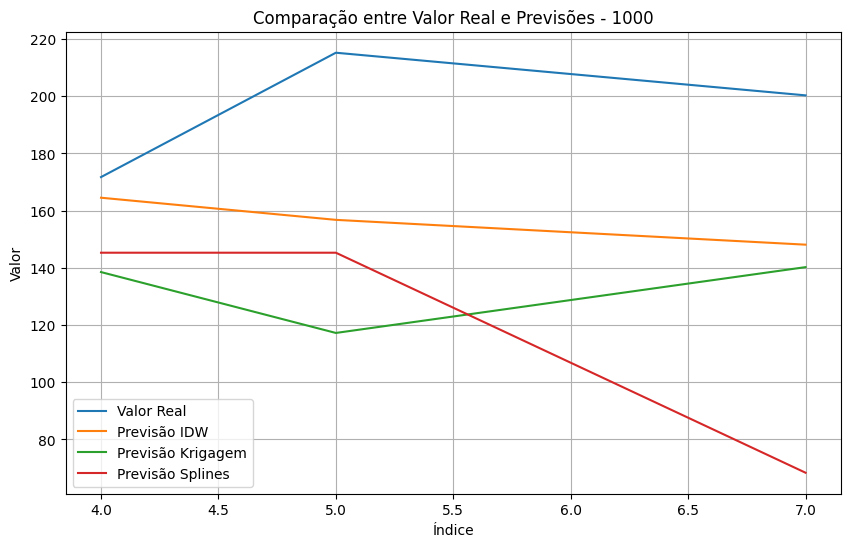

Krigagem
    MAE: 42.102905554526366
    MSE: 2684.0949420502916
    RMSE: 51.808251679151375
    MAPE: 21.96310498402013


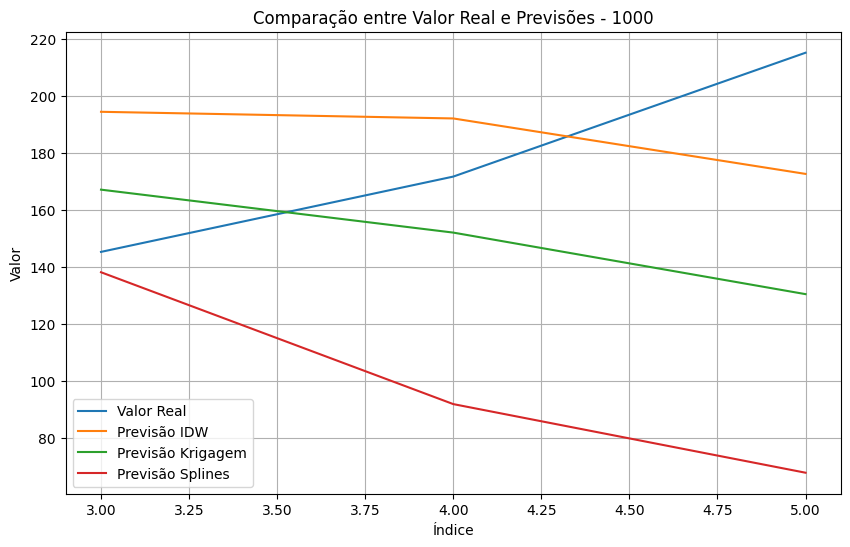

Splines
    MAE: 20.73223583929543
    MSE: 569.6105056031179
    RMSE: 23.866514316152617
    MAPE: 10.489560758918142


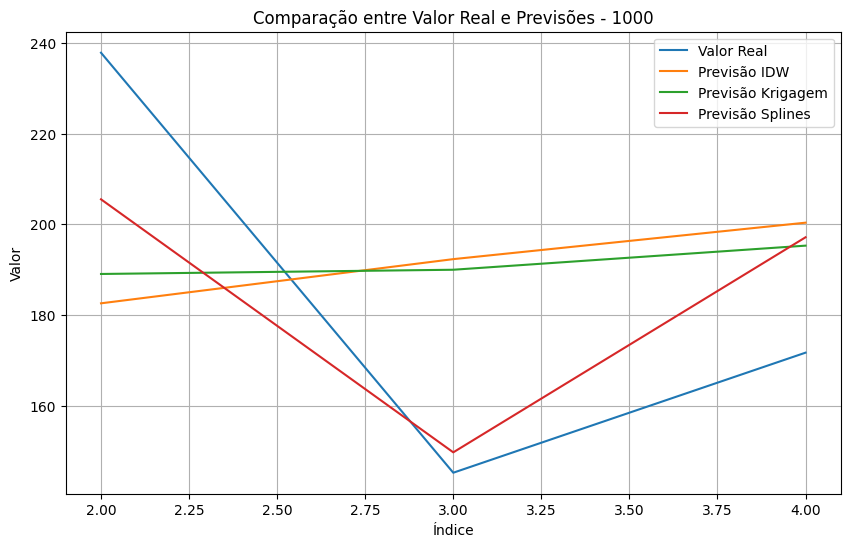

In [ ]:
import matplotlib.pyplot as plt

for metodo, previsao_coluna in [('IDW', 'previsao_IDW'), ('Krigagem', 'previsao_Krigagem'), ('Splines', 'previsao_Splines')]:
        print(metodo)
        mae, mse, rmse, mape = calcular_metricas(best_comb[metodo]['Total'].values, best_comb[metodo][previsao_coluna].values)
        print(f'    MAE: {mae}')
        print(f'    MSE: {mse}')
        print(f'    RMSE: {rmse}')
        print(f'    MAPE: {mape}')

        best_comb[metodo] = best_comb[metodo].sort_index()

        # Extrai os dados relevantes do DataFrame
        value = best_comb[metodo]['Total']
        previsao_IDW = best_comb[metodo]['previsao_IDW']
        previsao_Krigagem = best_comb[metodo]['previsao_Krigagem']
        previsao_Splines = best_comb[metodo]['previsao_Splines']


        # Cria o gráfico de linha
        plt.figure(figsize=(10, 6))
        plt.plot(value, label='Valor Real')
        plt.plot(previsao_IDW, label='Previsão IDW')
        plt.plot(previsao_Krigagem, label='Previsão Krigagem')
        plt.plot(previsao_Splines, label='Previsão Splines')
        plt.xlabel('Índice')
        plt.ylabel('Valor')
        plt.title('Comparação entre Valor Real e Previsões - 1000')
        plt.legend()
        plt.grid(True)
        plt.show()


#uhum


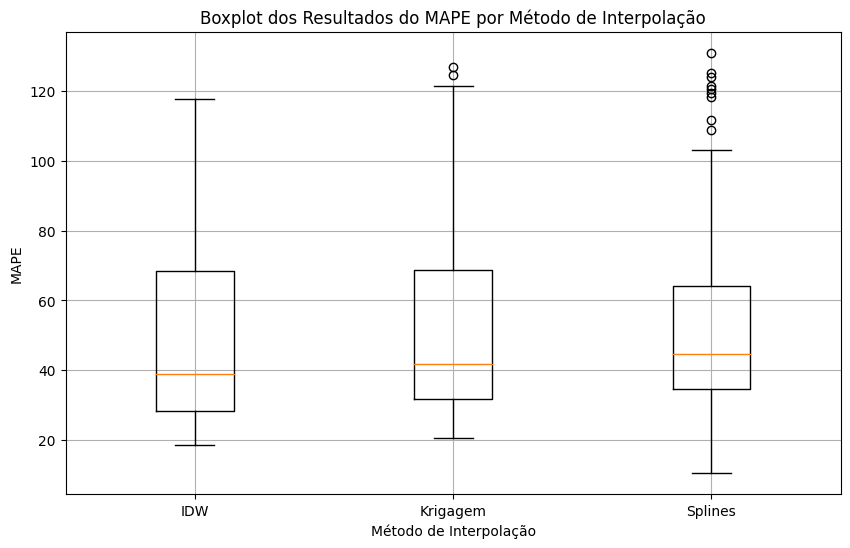

In [ ]:
import matplotlib.pyplot as plt

# Extrair os resultados do MAPE para cada método
mape_idw = [mape for mae, mse, rmse, mape in resultados_7_3['IDW']]
mape_krigagem = [mape for mae, mse, rmse, mape in resultados_7_3['Krigagem']]
mape_splines = [mape for mae, mse, rmse, mape in resultados_7_3['Splines']]

# Gerar o boxplot
plt.figure(figsize=(10, 6))
plt.boxplot([mape_idw, mape_krigagem, mape_splines], labels=['IDW', 'Krigagem', 'Splines'])
plt.title('Boxplot dos Resultados do MAPE por Método de Interpolação')
plt.xlabel('Método de Interpolação')
plt.ylabel('MAPE')
plt.grid(True)
plt.show()


In [ ]:
best_mape

{'IDW': 18.56897985917446,
 'Krigagem': 20.521243326557066,
 'Splines': 10.489560758918142}

In [ ]:
import pandas as pd
import numpy as np

# Função para calcular a distância Haversine entre dois pontos na Terra
def haversine(lat1, lon1, lat2, lon2):
    # Raio da Terra em quilômetros
    R = 6371.0

    # Conversão de graus para radianos
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    # Diferenças nas coordenadas
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    # Fórmula Haversine
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    # Distância em quilômetros
    distance = R * c
    return distance

# Exemplo de DataFrame com as colunas latitude e longitude
data = {
    'latitude': pivot['latitude'],
    'longitude': pivot['longitude']
}
df = pd.DataFrame(data)

# Calcula a distância entre todas as localizações
distances = pd.DataFrame(
    np.zeros((len(df), len(df))),
    columns=df.index,
    index=df.index
)


# Inicializa uma matriz de distâncias com zeros
distances = np.zeros((len(df), len(df)))

# Calcula a distância euclidiana entre todas as localizações
for i in range(len(df)):
    for j in range(len(df)):
        if i != j:
            delta_lat = df.iloc[i]['latitude'] - df.iloc[j]['latitude']
            delta_lon = df.iloc[i]['longitude'] - df.iloc[j]['longitude']
            distances[i, j] = np.sqrt(delta_lat**2 + delta_lon**2)

print(distances)


[[0.         0.02209072 0.03       0.05994164 0.05707013 0.0735459
  0.11766053 0.18943337 0.1692956  0.15472181]
 [0.02209072 0.         0.02009975 0.04313931 0.03640055 0.05281098
  0.10089599 0.17288435 0.14721753 0.14783557]
 [0.03       0.02009975 0.         0.03067572 0.03275668 0.04809366
  0.08781799 0.15947727 0.14767871 0.12838857]
 [0.05994164 0.04313931 0.03067572 0.         0.01726268 0.02302173
  0.05800862 0.13       0.12206556 0.11095932]
 [0.05707013 0.03640055 0.03275668 0.01726268 0.         0.01649242
  0.06735726 0.13865785 0.11493476 0.12737849]
 [0.0735459  0.05281098 0.04809366 0.02302173 0.01649242 0.
  0.05470832 0.12452309 0.10016986 0.12250356]
 [0.11766053 0.10089599 0.08781799 0.05800862 0.06735726 0.05470832
  0.         0.07200694 0.09972462 0.08089764]
 [0.18943337 0.17288435 0.15947727 0.13       0.13865785 0.12452309
  0.07200694 0.         0.11661904 0.09164088]
 [0.1692956  0.14721753 0.14767871 0.12206556 0.11493476 0.10016986
  0.09972462 0.116619